<h4 style="color:yellow;font-weight:bold;">
TỔNG QUAN DỰ ÁN
</h4>

<span style="color:green; font-size:20px;"><b>Bối cảnh</b></span>

Trong ngành dịch vụ tài chính, các tổ chức cho vay phải đối mặt với thách thức lớn trong việc **quản lý rủi ro tín dụng** trong khi vẫn phải duy trì lợi nhuận. Việc đánh giá chính xác khả năng trả nợ của người vay là yếu tố then chốt để **giảm thiểu nợ xấu** và đảm bảo các hoạt động cho vay bền vững.

 <span style="color:green; font-size:20px;"><b>Mục tiêu dự án</b></span>

Mục tiêu chính của dự án này là xây dựng một hệ thống phân tích và dự báo rủi ro tín dụng toàn diện dựa trên dữ liệu khách hàng vay vốn. Các mục tiêu cụ thể bao gồm:

  - **Khám phá dữ liệu (EDA):**  
    Nhận diện các đặc điểm quan trọng ảnh hưởng đến khả năng hoàn trả khoản vay như thu nhập, mục đích vay và tình trạng sở hữu nhà ở.

  - **Xử lý và chuẩn hóa dữ liệu:**  
    Áp dụng các kỹ thuật tiên tiến (như Yeo-Johnson Transformation và Scaling) để nắn chỉnh các biến số bị lệch, giúp tối ưu hóa hiệu suất cho các mô hình máy học.

  - **Phân khúc khách hàng (Clustering):**  
    Sử dụng thuật toán K-Means để chia nhóm khách hàng dựa trên sự tương đồng về đặc điểm định tính và mức độ rủi ro, từ đó hỗ trợ doanh nghiệp xây dựng chiến lược quản lý rủi ro phù hợp cho từng nhóm.

  - **Xây dựng mô hình dự báo (Classification):**  
    Thử nghiệm và so sánh nhiều thuật toán khác nhau (Logistic Regression, Random Forest, XGBoost...) để tìm ra mô hình có khả năng phân loại nợ xấu chính xác nhất.



<span style="color:green; font-size:20px;"><b>Các biến số chính</b></span>

**Biến mục tiêu (Target Variable)**

* `loan_status`: Trạng thái khoản vay 

**Biến độc lập (Independent Variables)**
 |Tên biến|Mô tả|
 |---|---| 
 |`person_age`| Tuổi của khách hàng|
 |`person_income`| Thu nhập hàng năm|
 |`person_emp_length`| Thâm niên làm việc (tính theo năm)|
 |`person_home_ownership`| Tình trạng sở hữu nhà ở|
 |`loan_amnt`| Số tiền vay|
 |`loan_int_rate`| Lãi suất|
 |`loan_grade`| Xếp hạng rủi ro khoản vay (A–G)|
 |`loan_intent`| Mục đích vay vốn|
 |`loan_percent_income`| Tỷ lệ khoản vay trên tổng thu nhập|
 |`cb_person_cred_hist_length`| Độ dài lịch sử tín dụng|
 |`cb_person_default_on_file`| Chỉ số từng có nợ xấu trong quá khứ| 


  <br>

<span style="color:green; font-size:20px;"><b>Nguồn dữ liệu</b></span>

Dữ liệu được lấy từ Kaggle, bao gồm thông tin về khách hàng vay vốn và trạng thái khoản vay. Bao gồm hơn 32581 dòng với 12 cột dữ liệu. Dữ liệu này sẽ được sử dụng để xây dựng các mô hình phân tích và dự báo rủi ro tín dụng, giúp doanh nghiệp đưa ra quyết định cho vay chính xác hơn. Link: `https://www.kaggle.com/datasets/laotse/credit-risk-dataset`


<h4 style="color:yellow;font-weight:bold;">
CÀI ĐẶT CÁC THƯ VIỆN CẦN THIẾT
</h4>

In [ ]:
!pip install scikit-learn
!pip install optuna
!pip install ipython
!pip install xgboost lightgbm catboost
!pip install jinja2
!pip install scipy pingouin
!pip install imbalanced-learn

<h4 style="color:yellow;font-weight:bold;">
IMPORT CÁC THƯ VIỆN CẦN THIẾT
</h4>

In [2]:
# import library

import pandas as pd              
import numpy as np              
import seaborn as sns            
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

from scipy.stats import normaltest, mannwhitneyu
from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.cluster import KMeans

<h4 style="color:yellow;font-weight:bold;">
ĐỌC DỮ LIỆU VÀ KHÁM PHÁ BAN ĐẦU
</h4>

In [3]:
# Đọc dữ liệu
df = pd.read_csv("C:\\Users\\dell\\OneDrive\\Documents\\PROJECT\\CREDIT RISK\\DATA RAW\\credit_risk_dataset.csv")
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns] 
df.info()

# Biến số
num_features = ["person_age", "person_income", "person_emp_length", 
                "loan_amnt", "loan_int_rate", "loan_percent_income", 
                "cb_person_cred_hist_length"]

# Biến phân loại
cat_features = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

# Thống kê mô tả cho biến định lượng
cm = sns.light_palette("orange", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


,count,mean,std,min,25%,50%,75%,max
person_age,32581.000000,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,144.000000
person_income,32581.000000,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6000000.000000
person_emp_length,31686.000000,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,123.000000
loan_amnt,32581.000000,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,35000.000000
loan_int_rate,29465.000000,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,23.220000
loan_percent_income,32581.000000,0.170203,0.106782,0.000000,0.090000,0.150000,0.230000,0.830000
cb_person_cred_hist_length,32581.000000,5.804211,4.055001,2.000000,3.000000,4.000000,8.000000,30.000000


<span style="color:white; font-size:20px;"><b>Thống kê mô tả biến định lượng </b></span>

* `person_age`: Trung bình ~27.7; trung vị ~26; độ tuổi dao động từ 20-144 tuổi → chủ yếu là nhóm tuổi trẻ, có giá trị tối đa rất lớn (có thể do lỗi dữ liệu).

* `person_income`: Trung bình ~66K; trung vị ~55K; mức thu nhập dao động từ 4K-6M → phân phối lệch phải mạnh, có nhiều giá trị ngoại lai.

* `person_emp_length`: Trung bình ~4.79 năm; trung vị ~4 năm; số năm kinh nghiệm dao động từ 0-123 năm → nhìn chung khách hàng có số năm làm việc ngắn, có một số giá trị bất thường (có thể do lỗi dữ liệu).

* `loan_amnt`: Trung bình ~9.6K; trung vị ~8K; khoản vay dao động từ 500-35K → khoản vay phân bố ở mức vừa phải.

* `loan_int_rate`: Trung bình ~11%; trung vị ~11%; lãi suất dao động từ 5.4%-23.2% → lãi suất phổ biến, mức biến động trung bình.

* `loan_percent_income`: Trung bình ~17%; trung vị ~15%; tỷ lệ khoản vay so với thu nhập dao động từ 0-83% → biến động mạnh, cho thấy có một số người vay tỷ lệ rất cao so với thu nhập.

* `cb_person_cred_hist_length`: Trung bình ~5.8 năm; trung vị ~4 năm; lịch sử tín dụng dao động từ 2-30 năm → phần lớn khách hàng có lịch sử tín dụng khá ngắn.



In [4]:
# Thống kê mô tả cho biến định tính
display(df[cat_features].describe().T.style.background_gradient(cmap="Oranges", subset=["unique", "freq"]))

,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


<span style="color:white; font-size:20px;"><b>Thống kê mô tả biến định tính</b></span>


* `person_home_ownership`: 4 nhóm; phần lớn khách hàng là **thuê nhà (~50%)** → cho thấy nhiều người vay không sở hữu tài sản nhà ở, có thể làm tăng rủi ro tín dụng.

* `loan_intent`: 6 nhóm; **mục đích vay giáo dục** phổ biến nhất → cho thấy nhu cầu vay phục vụ học tập khá cao.

* `loan_grade`: 7 mức (A–G); đa số thuộc **hạng A** → dữ liệu nghiêng về nhóm khách hàng rủi ro thấp.

* `cb_person_default_on_file`: Nhị phân; đa số **không có lịch sử vỡ nợ (~82%)** → tỷ lệ vỡ nợ trong quá khứ tương đối thấp.



<h4 style="color:yellow;font-weight:bold;">
KIỂM TRA CHẤT LƯỢNG DỮ LIỆU
</h4>

In [5]:
# Missing values (giá trị bị thiếu)
print("="*30, "CHECKING NULL VALUES", "="*30)
missing_count = df.isnull().sum()
missing_only = missing_count[missing_count > 0]
if not missing_only.empty:
    print(f"Phát hiện {len(missing_only)} cột bị thiếu dữ liệu:")
    print(missing_only, "\n")
else:
    print("Không có giá trị thiếu nào trong dataset.\n")

# Duplicate values (dòng bị trùng lặp)
print("="*30, "CHECKING DUPLICATE ROWS", "="*30)
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"Phát hiện {duplicate_count} dòng bị trùng lặp.\n")
else:
    print("Không có dòng trùng lặp nào trong dataset.\n")

# Outlier (giá trị ngoại lai)
def checking_outlier(list_feature, df):
    print("=" * 30, "CHECKING OUTLIER", "=" * 30)

    outlier_info = []

    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]

        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers)})      
    return pd.DataFrame(outlier_info)

checking_outlier( list_feature=num_features, df=df,)


============================== CHECKING NULL VALUES ==============================
Phát hiện 2 cột bị thiếu dữ liệu:
person_emp_length     895
loan_int_rate        3116
dtype: int64 

============================== CHECKING DUPLICATE ROWS ==============================
Phát hiện 165 dòng bị trùng lặp.

============================== CHECKING OUTLIER ==============================


,Feature,Outlier Count
0,person_age,1494
1,person_income,1484
2,person_emp_length,853
3,loan_amnt,1689
4,loan_int_rate,6
5,loan_percent_income,651
6,cb_person_cred_hist_length,1142


<span style="color:green; font-size:20px;"><b>Đánh giá Chất lượng Dữ liệu</b></span>

<span style="color:white; font-size:20px;"><b>Giá trị bị thiếu</b></span>

**Phát hiện giá trị thiếu ở 2 biến:**

* `loan_int_rate`: thiếu 3,116 giá trị (~9.56%) → mức thiếu khá lớn và cần được xử lý ở bước tiền xử lý.
* `person_emp_length`: thiếu 895 giá trị (~2.75%) → mức thiếu tương đối nhỏ nhưng vẫn cần xử lý.

<span style="color:white; font-size:20px;"><b>Dòng bị trùng lặp </b></span>

* Phát hiện 165 dòng bị trùng lặp hoàn toàn, chiếm khoảng 0.5% tổng dữ liệu → mức trùng lặp thấp nhưng vẫn nên loại bỏ để đảm bảo chất lượng phân tích.

<span style="color:white; font-size:20px;"><b>Giá trị ngoại lai </b></span>

**Giá trị ngoại lai xuất hiện ở nhiều biến số, cho thấy sự biến động lớn giữa các hồ sơ người vay.**
* `person_age`: có 1494 giá trị ngoại lai
* `person_income`: có 1484 giá trị ngoại lai
* `person_emp_length`: có 853 giá trị ngoại lai    
* `loan_amnt`: có 1689 giá trị ngoại lai
* `loan_int_rate`: có 6 giá trị ngoại lai
* `loan_percent_income`: có 651 giá trị ngoại lai
* `cb_person_cred_hist_length`: có 1142 giá trị ngoại lai

Giá trị ngoại lai (outliers) được xác định bằng phương pháp IQR (Interquartile Range).
Phương pháp này sử dụng khoảng tứ phân vị để phát hiện các giá trị nằm quá xa so với phần lớn dữ liệu. Tuy nhiên vẫn có một số giá trị ngoại lai có thể phản ánh các trường hợp thực tế (ví dụ: người vay có thu nhập rất cao hoặc tuổi tác rất lớn), do đó cần xem xét kỹ lưỡng trước khi quyết định loại bỏ chúng.

<h4 style="color:yellow;font-weight:bold;">
PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)
</h4>

<h4 style="color:green;font-weight:bold;font-size:18px;">
PHÂN PHỐI BIẾN MỤC TIÊU
</h4>

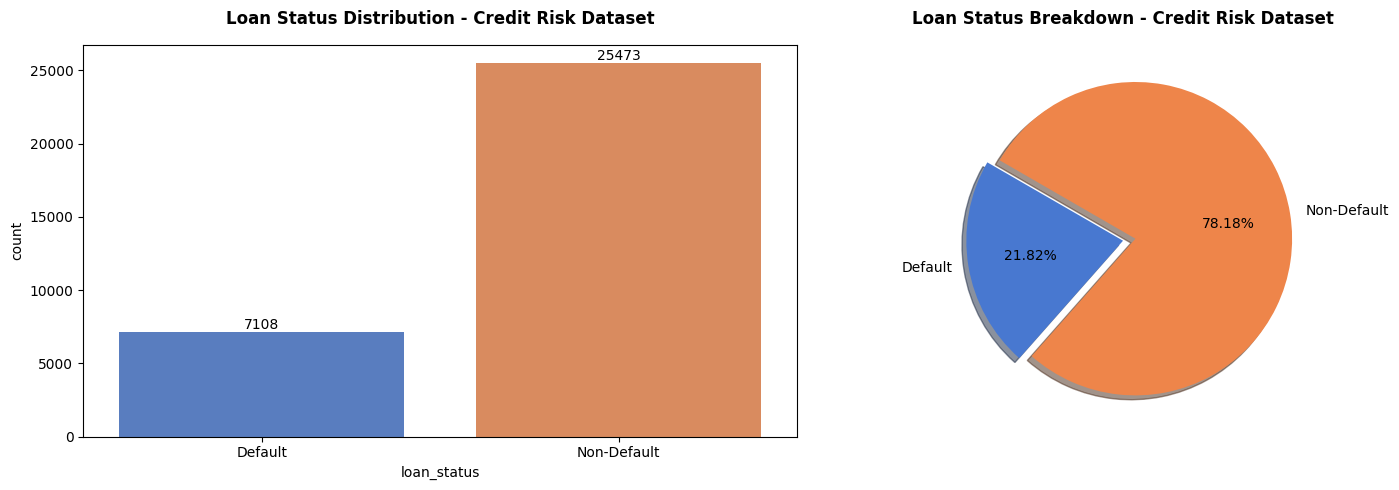

In [6]:
TARGET_COLUMN = "loan_status" 
DATASET_NAME = "Credit Risk Dataset"

df_credit = df.copy()
mapping = {0: "Non-Default", 1: "Default"} # Giả sử 0 là Non-Default (không vỡ nợ) và 1 là Default (vỡ nợ)
df_credit[TARGET_COLUMN] = df_credit[TARGET_COLUMN].map(mapping)

order = ["Default", "Non-Default"]
loan_status_distribution = df_credit[TARGET_COLUMN].value_counts().reindex(order)
n_color = sns.color_palette("muted", n_colors=len(order))
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Biểu đồ cột
sns.countplot(data=df_credit, x=TARGET_COLUMN,hue=TARGET_COLUMN,palette=n_color,ax=ax[0],order=order,legend=False)
ax[0].set_title(f"Loan Status Distribution - {DATASET_NAME}", weight="bold", 
                fontsize=12, pad=15)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%d", label_type="edge", fontsize=10)

# Biểu đồ tròn
ax[1].pie(loan_status_distribution,labels=order,colors=n_color,autopct="%1.2f%%",startangle=150,explode=(0, 0.08),shadow=True)
ax[1].set_title(f"Loan Status Breakdown - {DATASET_NAME}", weight="bold", 
                fontsize=12, pad=15)

# Điều chỉnh layout và hiển thị
plt.tight_layout()
plt.show()

<span style="color:white; font-size:20px;"><b>Phân tích phân phối biến mục tiêu</b></span>

**Trước hết chúng ta sẽ giả định rằng biến mục tiêu `loan_status` đã được mã hóa thành hai lớp: `Non-Default` (không vỡ nợ) và `Default` (vỡ nợ). Phân phối của biến này cho thấy:**

* <b>Non-Default: 25473 khách hàng (~78.18%)</b> → phần lớn khách hàng có khả năng hoàn trả khoản vay đúng hạn.

* <b>Default: 7108 khách hàng (~21.82%)</b> → đại diện cho nhóm khách hàng có rủi ro không trả được nợ.

Bộ dữ liệu có hiện tượng <b>mất cân bằng lớp ở mức vừa phải</b>, với tỷ lệ xấp xỉ <b>1:4</b> giữa nhóm vỡ nợ và không vỡ nợ.

Tỷ lệ vỡ nợ (~22%) <b>cao hơn đáng kể</b> so với nhiều bộ dữ liệu ngân hàng thông thường → giúp mô hình học được tín hiệu phân loại rõ ràng hơn.



<h4 style="color:green;font-weight:bold;font-size:18px;">
PHÂN PHỐI BIẾN ĐỊNH LƯỢNG
</h4>

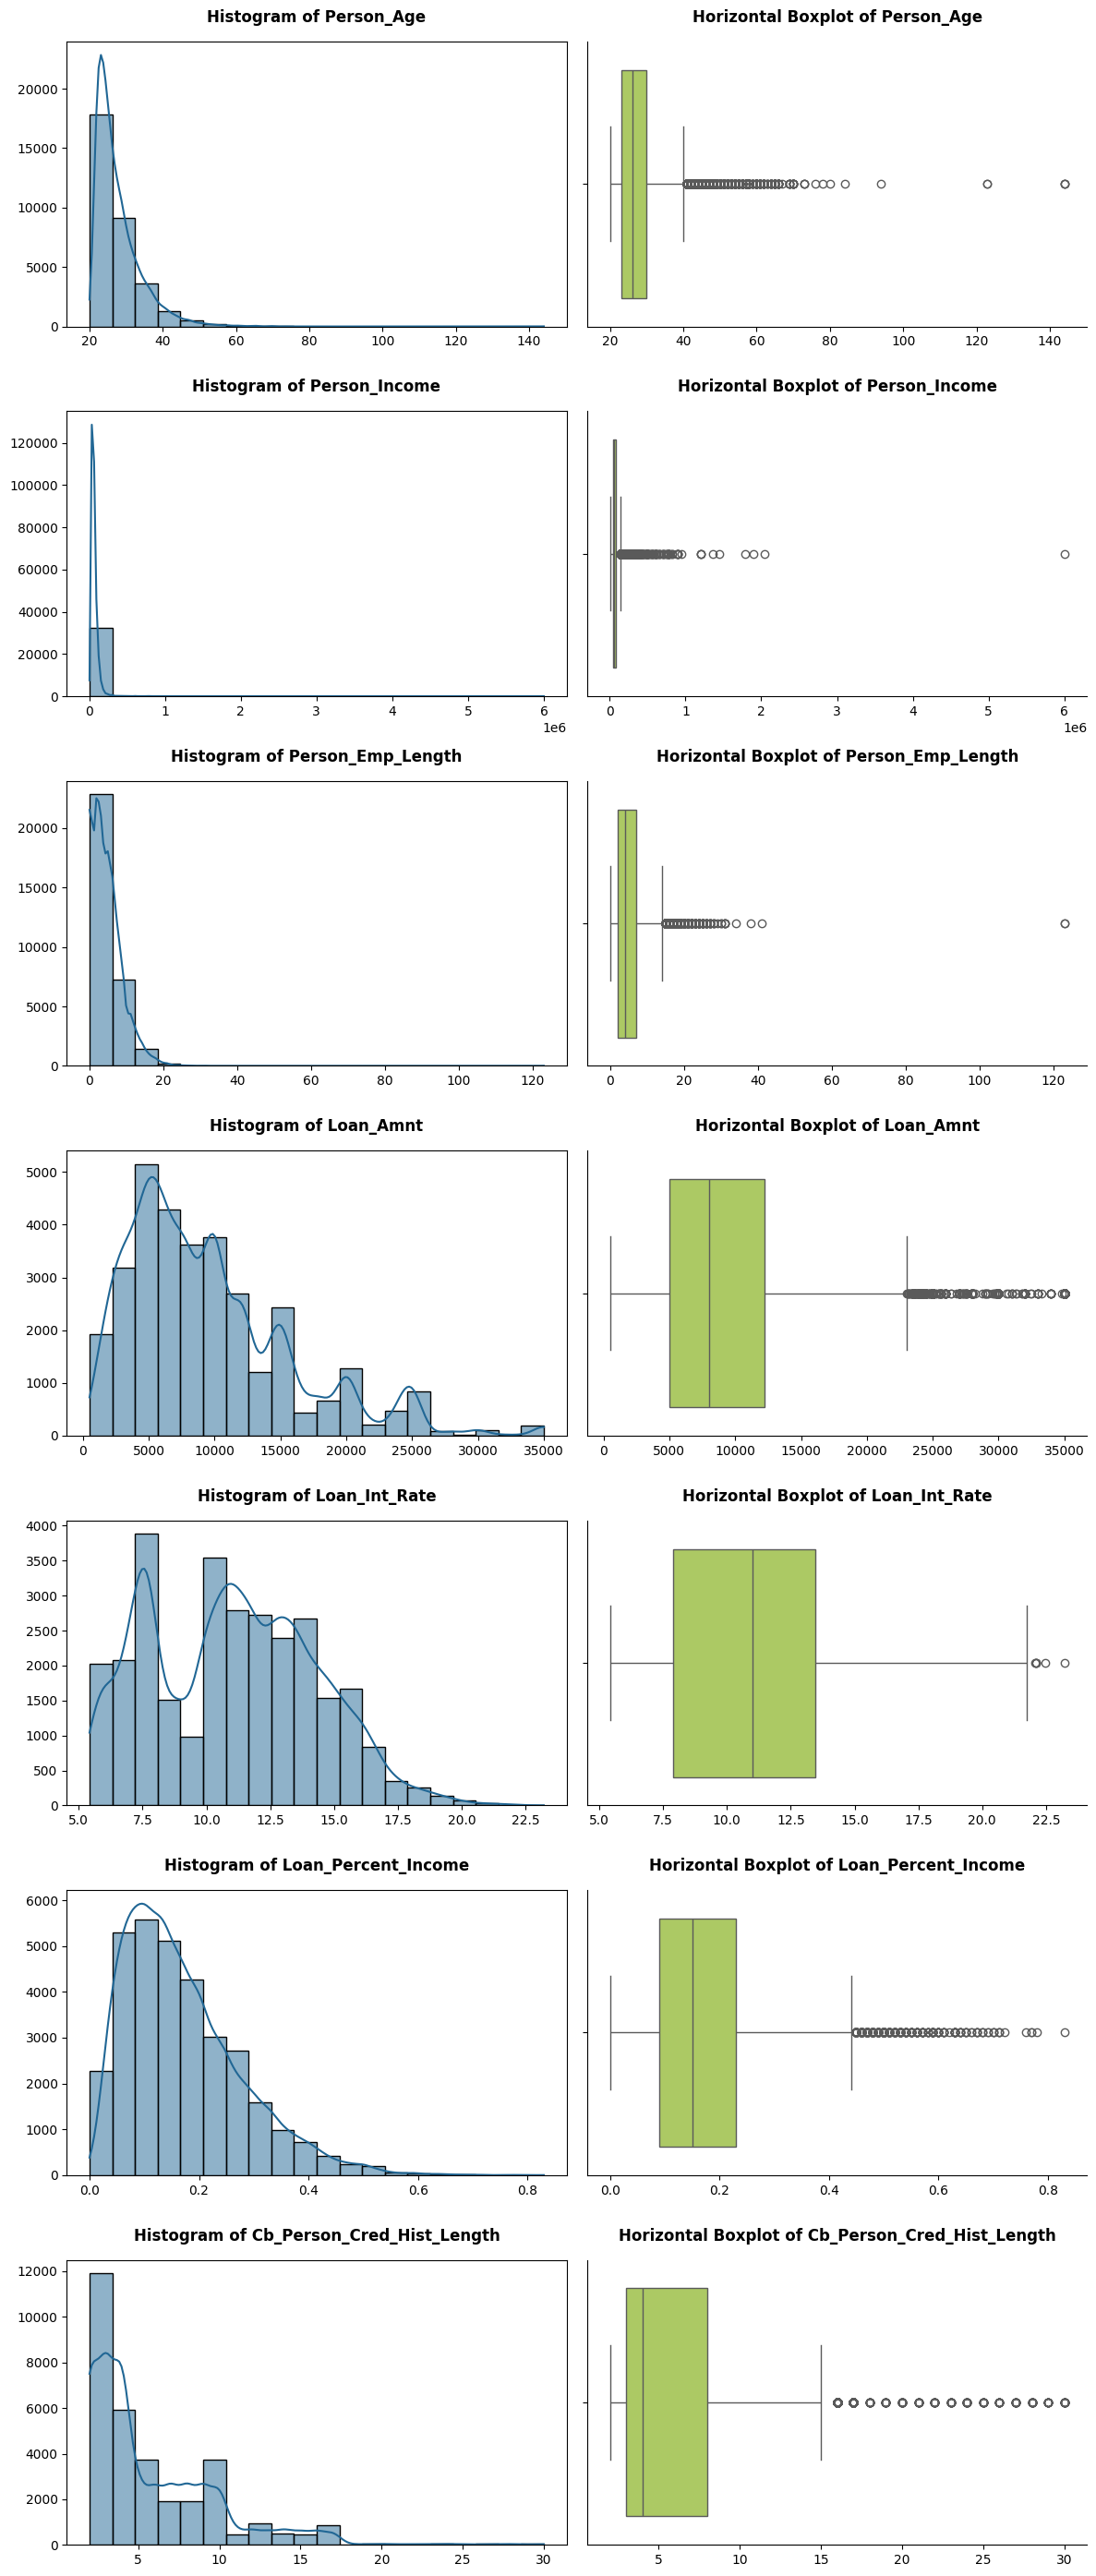

In [7]:
# VẼ BIỂU ĐỒ PHÂN PHỐI

def plot_numerical_features(df=df, numerical_features = num_features):
    fig, ax = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(numerical_features):
        # Vẽ biểu đồ cột và KDE
        sns.histplot(data=df[feature], color="#216795", bins = 20, kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature.title()}", weight="bold", fontsize=12, pad=15)
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")
        # Vẽ biểu đồ boxplot ngang
        sns.boxplot(data=df[feature], color="#B3DA53D3", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Boxplot of {feature.title()}", weight="bold", fontsize=12, pad=15)
        ax[i, 1].set_xlabel("")
        sns.despine(ax=ax[i, 1], top=True, right=True, left=False, bottom=False)
    # Điều chỉnh layout và hiển thị
    plt.tight_layout()
    plt.show()
plot_numerical_features()

In [8]:
# KIỂM TRA ĐỘ LỆCH

def check_skewness(data=df, numerical_features=num_features, sort=True):
    skewness_dict = {}
    skew_feature = []

    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])

    if sort:
        skew_df = skew_df.reindex(
            skew_df["Skewness"].abs().sort_values(ascending=False).index)
    print(f"\nSkewness for dataset:")
    print("-" * 70)
    print(f"{'Feature':<30} | {'Skewness':<10} | {'Remark'}")
    print("-" * 70)

    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)

        if abs_skew > 1:
            remark = "Highly skewed" # phân phối bị lệch mạnh
            skew_feature.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed" # phân phối bị lệch vừa phải
            skew_feature.append(feature)
        else:
            remark = "Approximately symmetric" # phân phối gần như đối xứng

        print(f"{feature:<30} | {skew:>+10f} | {remark}")

    print("-" * 70)

    return skew_feature, skew_df
skew_feature, skew_df = check_skewness()



Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
person_income                  | +32.865349 | Highly skewed
person_emp_length              |  +2.614455 | Highly skewed
person_age                     |  +2.581393 | Highly skewed
cb_person_cred_hist_length     |  +1.661790 | Highly skewed
loan_amnt                      |  +1.192477 | Highly skewed
loan_percent_income            |  +1.064669 | Highly skewed
loan_int_rate                  |  +0.208550 | Approximately symmetric
----------------------------------------------------------------------


<span style="color:white; font-size:20px;"><b>Phân tích phân phối biến định lượng</b></span>
* Phần lớn các biến số trong bộ dữ liệu có **phân phối lệch phải**, cho thấy dữ liệu tập trung chủ yếu ở các giá trị thấp và xuất hiện đuôi dài cùng nhiều **giá trị ngoại lai**, đặc biệt là ở các biến như `person_income`, `loan_amnt` và `loan_percent_income`. 

* **6 trên 7 biến có độ lệch cao** (skewness > 1), cho thấy sự lệch phải mạnh mẽ trong phân phối dữ liệu. Điều này có thể ảnh hưởng đến hiệu suất của các mô hình máy học, đặc biệt là những mô hình nhạy cảm với phân phối dữ liệu như **Logistic Regression**. Do đó, việc áp dụng các kỹ thuật nắn chỉnh (như Yeo-Johnson Transformation) sẽ rất cần thiết để cải thiện hiệu suất mô hình.

* Biến `loan_int_rate` có độ lệch thấp hơn (skewness ~0.2), cho thấy phân phối của nó **gần với phân phối chuẩn** hơn so với các biến khác, điều này có thể giúp mô hình học được tín hiệu tốt hơn từ biến này mà không cần nắn chỉnh quá nhiều.


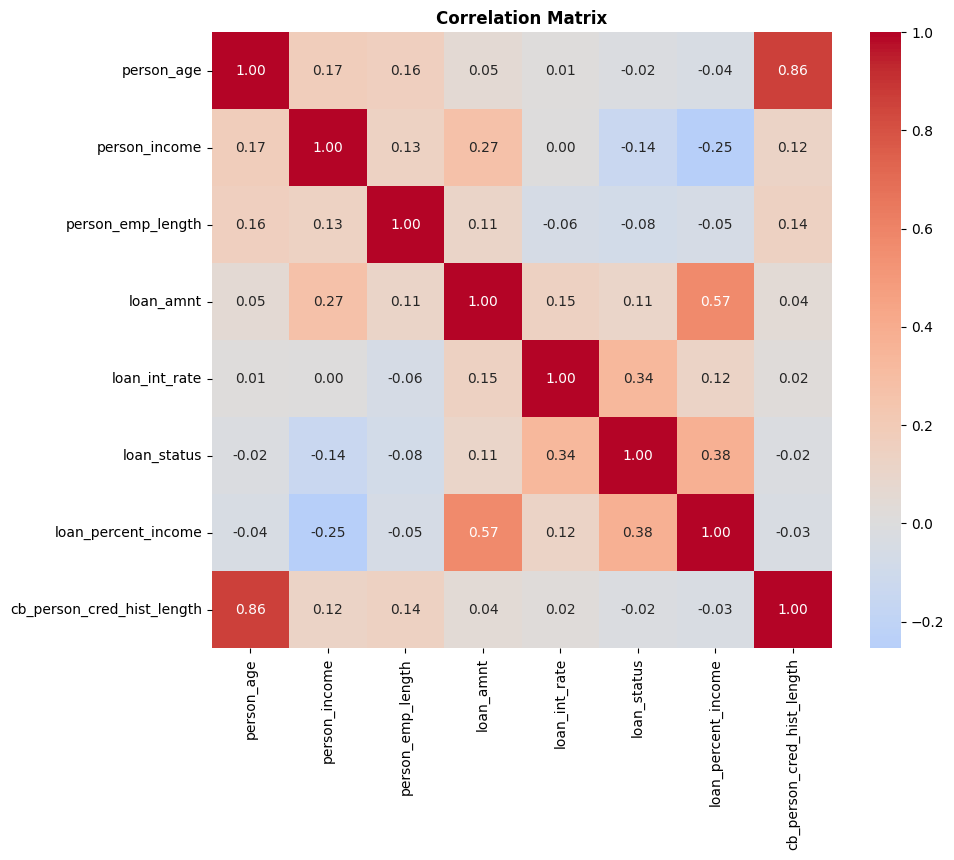

In [9]:
# MA TRẬN TƯƠNG QUAN 

from scipy.stats import pearsonr
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Matrix", weight='bold')
plt.show()

<span style="color:white; font-size:20px;"><b>Nhận xét ma trận tương quan</b></span>

* **Phần lớn các biến có mức tương quan thấp đến trung bình**, cho thấy hiện tượng đa cộng tuyến không quá nghiêm trọng.

* **`person_age` và `cb_person_cred_hist_length`** có tương quan rất mạnh (0.86), phản ánh khách hàng lớn tuổi thường có lịch sử tín dụng dài hơn.

* **`loan_amnt` và `loan_percent_income`** có tương quan dương khá cao (0.57), cho thấy khoản vay lớn thường chiếm tỷ lệ cao hơn so với thu nhập.

* **`loan_status`** có tương quan dương với **`loan_percent_income`** (0.38) và **`loan_int_rate`** (0.34), cho thấy khách hàng vay nhiều so với thu nhập hoặc có lãi suất cao thường có nguy cơ vỡ nợ lớn hơn.

* **Nhìn chung, các mối quan hệ trong dữ liệu phản ánh khá hợp lý đặc điểm thực tế của rủi ro tín dụng.**

<h4 style="color:green;font-weight:bold;font-size:18px;">
PHÂN PHỐI BIẾN ĐỊNH LƯỢNG
</h4>

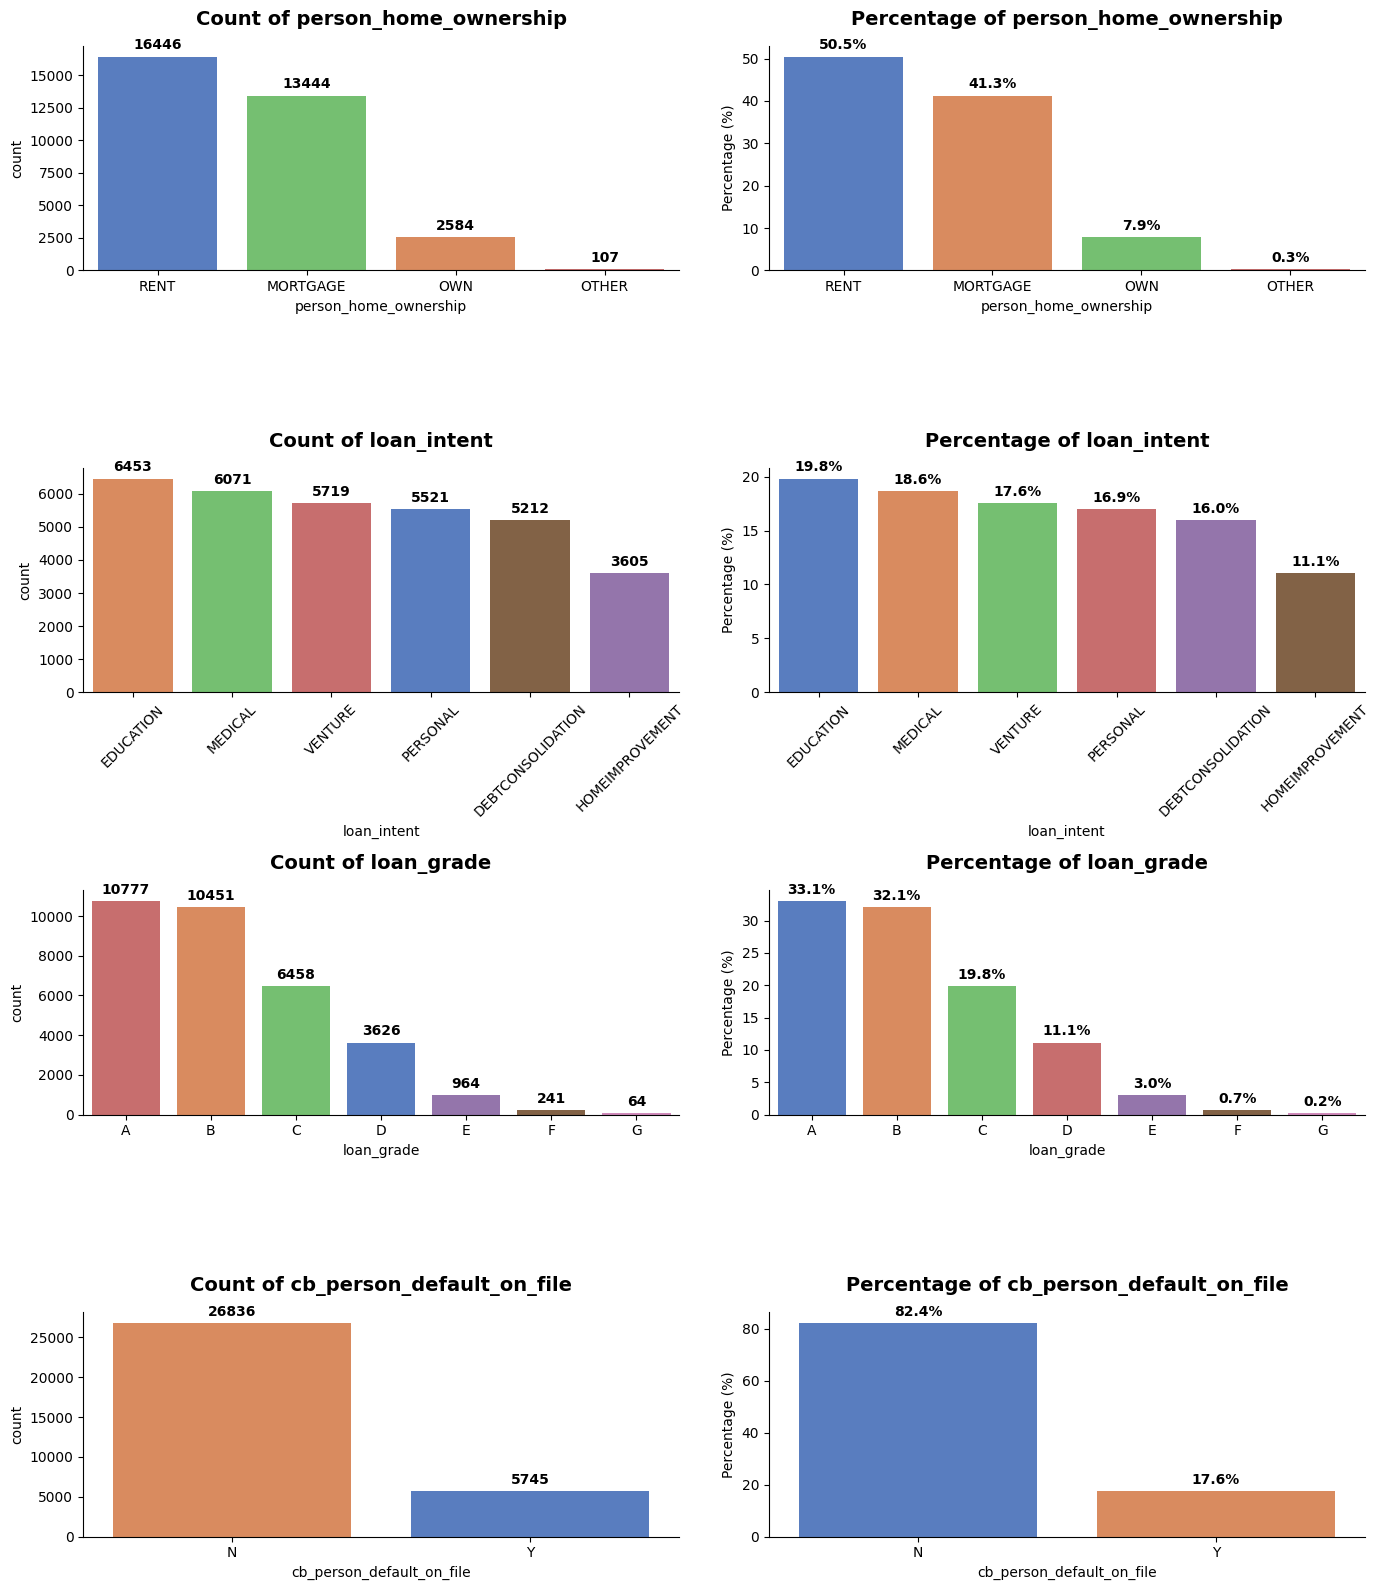

In [10]:
def plot_categorical_distribution(df, cat_features):
    fig, ax = plt.subplots(len(cat_features), 2, figsize=(14, len(cat_features)*4))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(cat_features):
        order = df[feature].value_counts().index
        palette = sns.color_palette("muted", n_colors=len(df[feature].unique()))

        # BIỂU ĐỒ CỘT (COUNT)
        sns.countplot(data=df, x=feature, order=order,
            ax=ax[i, 0], hue=feature, palette=palette, legend=False)

        ax[i, 0].set_title(f"Count of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 0].set_xlabel(feature)
        sns.despine(ax=ax[i, 0], top=True, right=True)
        # Gắn nhãn số lượng trên mỗi cột
        for container in ax[i, 0].containers:
            ax[i, 0].bar_label(
                container,
                padding=3,
                fmt='%d',
                fontsize=10,
                fontweight="bold")

        # Tạo dataframe tạm để tính phần trăm
        feature_counts = df[feature].value_counts(normalize=True)
        percentage_df = (feature_counts * 100).round(2).reset_index()
        percentage_df.columns = [feature, "Percentage"]

        # BIỂU ĐỒ CỘT (%)
        sns.barplot(data=percentage_df, x=feature, y="Percentage", order=order,
            ax=ax[i, 1], hue=feature, palette=palette, legend=False)

        ax[i, 1].set_title(f"Percentage of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 1].set_ylabel("Percentage (%)")
        sns.despine(ax=ax[i, 1], top=True, right=True)

        for container_pct in ax[i, 1].containers:
            ax[i, 1].bar_label(
                container_pct,
                padding=3,
                fmt='%.1f%%',
                fontsize=10,
                fontweight="bold")

        # Xoay nhãn trục X đối với cột "loan_intent" để tránh bị chồng chéo
        if feature == "loan_intent":
            ax[i, 0].tick_params(axis="x", rotation=45)
            ax[i, 1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

plot_categorical_distribution(df=df, cat_features=cat_features)

<span style="color:white; font-size:20px;"><b>Phân tích phân phối biến định tính</b></span>

* **`person_home_ownership`**: Phần lớn khách hàng không sở hữu nhà, chủ yếu thuộc nhóm **RENT**(thuê nhà) (~50%) và **MORTGAGE**(vay mua nhà) (~41%), cho thấy mức độ sử dụng đòn bẩy tài chính ở mức vừa phải.

* **`loan_intent`**: Mục đích vay vốn phân bố khá đồng đều, trong đó các khoản vay cho **education**(giáo dục), **medical** (y tế) và **venture**(kinh doanh) chiếm tỷ trọng cao nhất (~17–20%), phản ánh nhu cầu vay đa dạng của khách hàng.

* **`loan_grade`** : Đa số khoản vay thuộc nhóm chất lượng cao (**Grade A & B** ~65%), cho thấy phần lớn khách hàng được đánh giá có rủi ro tín dụng thấp.

* **`cb_person_default_on_file`**: Phần lớn khách hàng không có lịch sử vỡ nợ trước đó (~82%), cho thấy tập khách hàng nhìn chung có độ tin cậy cao.


<h4 style="color:green;font-weight:bold;font-size:18px;">
PHÂN TÍCH 2 BIẾN (BIVARIATE ANALYSIS)
</h4>

In [11]:
# HÀM KIỂM ĐỊNH CHI-SQUARE

def cal_ChiSquare(cat_feature, target_feature, df, show_residuals=True):
    contingency_table = pd.crosstab(df[cat_feature], df[target_feature])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"\nChi-Square Test of Independence: '{cat_feature}' và '{target_feature}'")
    print(f"Giá trị Chi-square: {chi2:.3f}")
    print(f"Bậc tự do: {dof}")
    print(f"p-value: {p_value:.6f}")

    if p_value < 0.05:
        print("Kết quả: p-value < 0.05 -> Bác bỏ H0")
        print(
            f"Kết luận: Có mối liên hệ có ý nghĩa thống kê "
            f"giữa '{cat_feature}' và '{target_feature}'."
        )
    else:
        print("Kết quả: p-value >= 0.05 -> Không bác bỏ H0")
        print(
            f"Kết luận: Chưa đủ bằng chứng để nói rằng "
            f"'{cat_feature}' có mối liên hệ với '{target_feature}'."
        )

    if show_residuals:
        expected_df = pd.DataFrame(
            expected,
            index=contingency_table.index,
            columns=contingency_table.columns
        )

        standardized_residuals = (
            contingency_table - expected_df
        ) / np.sqrt(expected_df)

        print("\nStandardized Residuals:")
        print(standardized_residuals.round(2))
        plt.figure(figsize=(8, 5))
        sns.heatmap(
            standardized_residuals,
            annot=True,
            fmt=".2f",
            cmap="RdBu",
            center=0,
            linewidths=0.5,
            linecolor="white"
        )
        plt.title(
            f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}",
            fontsize=14
        )
        plt.xlabel(target_feature)
        plt.ylabel(cat_feature)
        plt.tight_layout()
        plt.show()


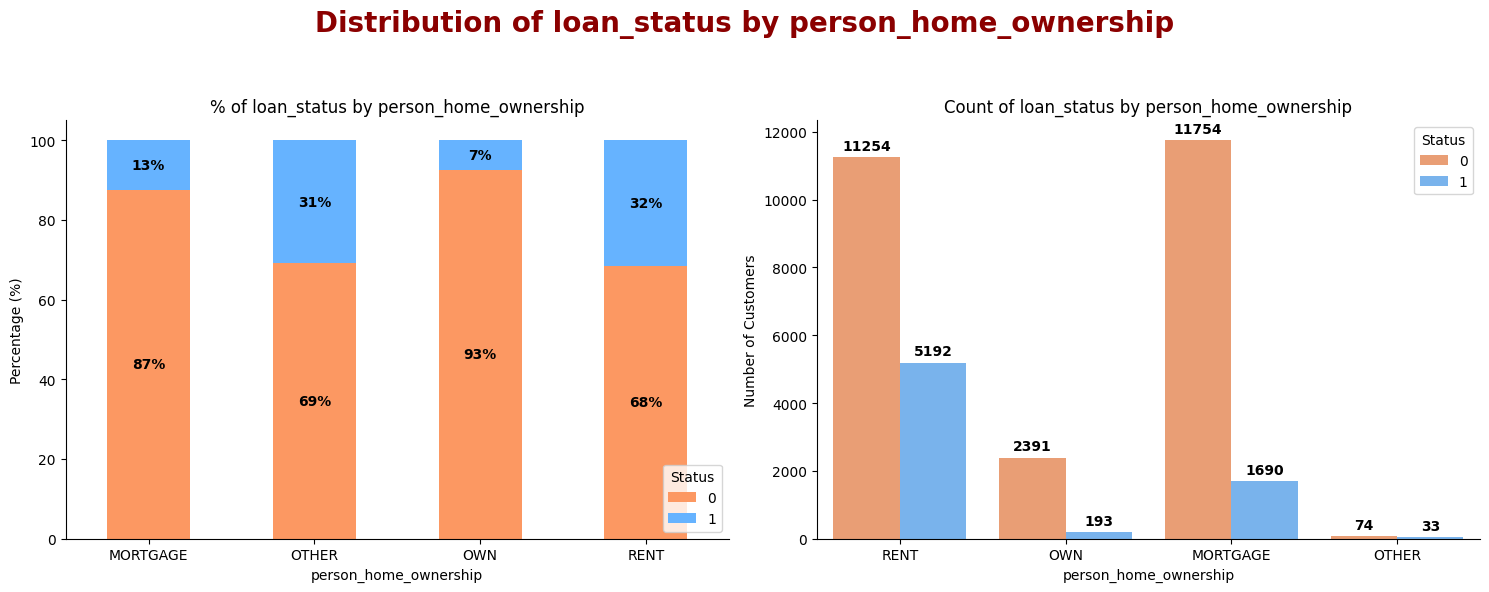


Chi-Square Test of Independence: 'person_home_ownership' và 'loan_status'
Giá trị Chi-square: 1907.981
Bậc tự do: 3
p-value: 0.000000
Kết quả: p-value < 0.05 -> Bác bỏ H0
Kết luận: Có mối liên hệ có ý nghĩa thống kê giữa 'person_home_ownership' và 'loan_status'.

Standardized Residuals:
loan_status                0      1
person_home_ownership              
MORTGAGE               12.12 -22.95
OTHER                  -1.06   2.00
OWN                     8.25 -15.61
RENT                  -14.15  26.78


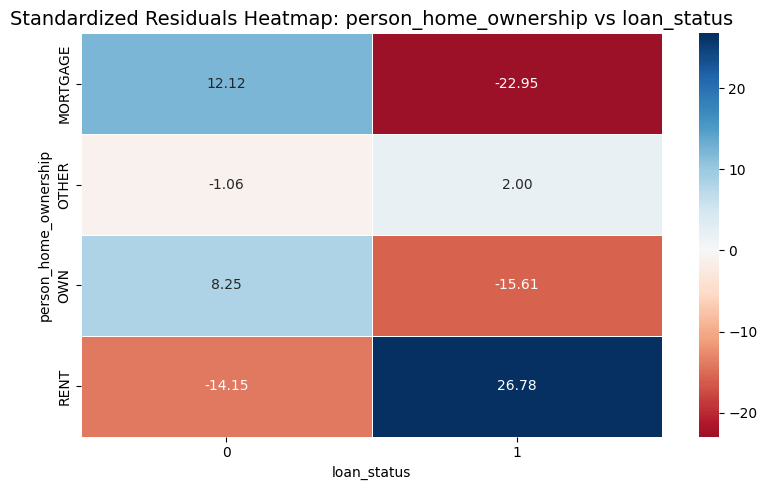

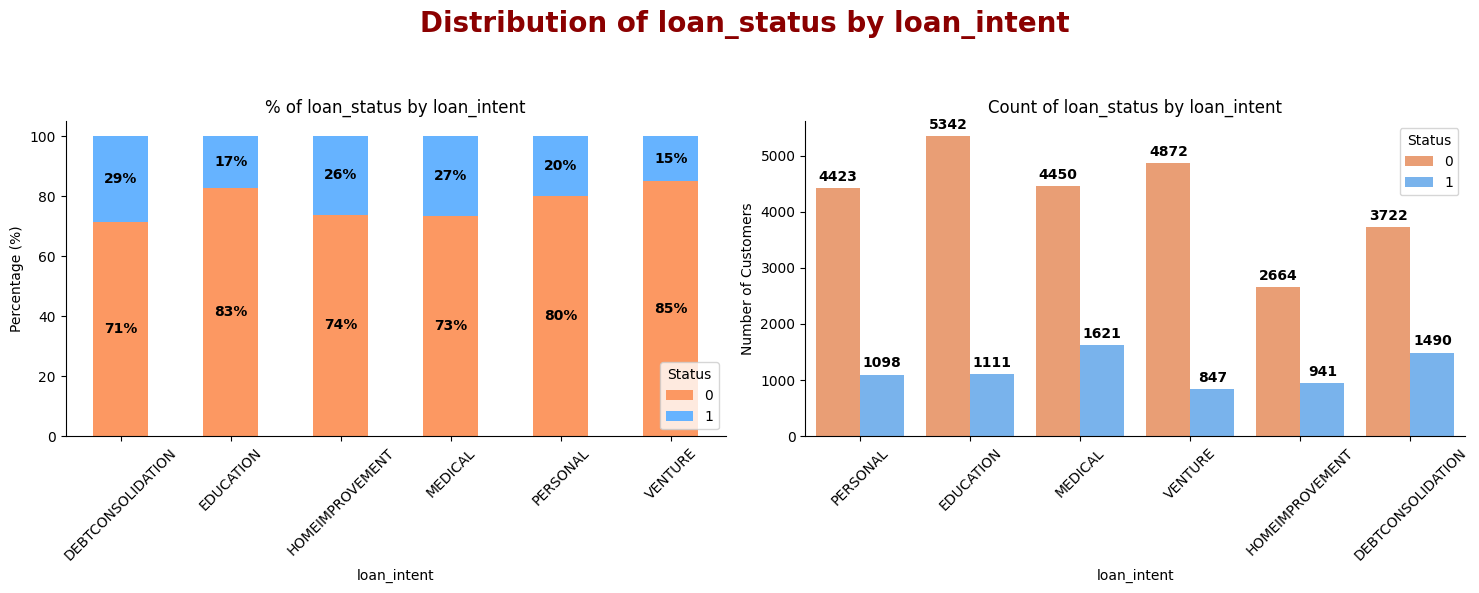


Chi-Square Test of Independence: 'loan_intent' và 'loan_status'
Giá trị Chi-square: 520.512
Bậc tự do: 5
p-value: 0.000000
Kết quả: p-value < 0.05 -> Bác bỏ H0
Kết luận: Có mối liên hệ có ý nghĩa thống kê giữa 'loan_intent' và 'loan_status'.

Standardized Residuals:
loan_status           0      1
loan_intent                   
DEBTCONSOLIDATION -5.53  10.47
EDUCATION          4.18  -7.91
HOMEIMPROVEMENT   -2.91   5.51
MEDICAL           -4.30   8.15
PERSONAL           1.62  -3.07
VENTURE            5.99 -11.34


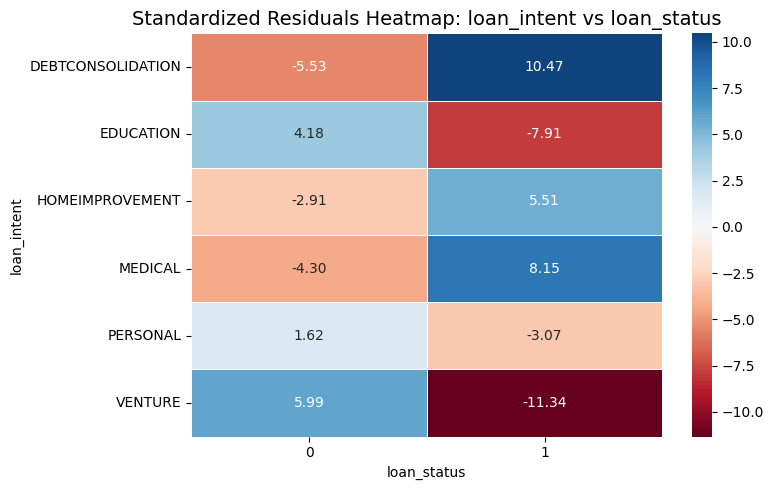

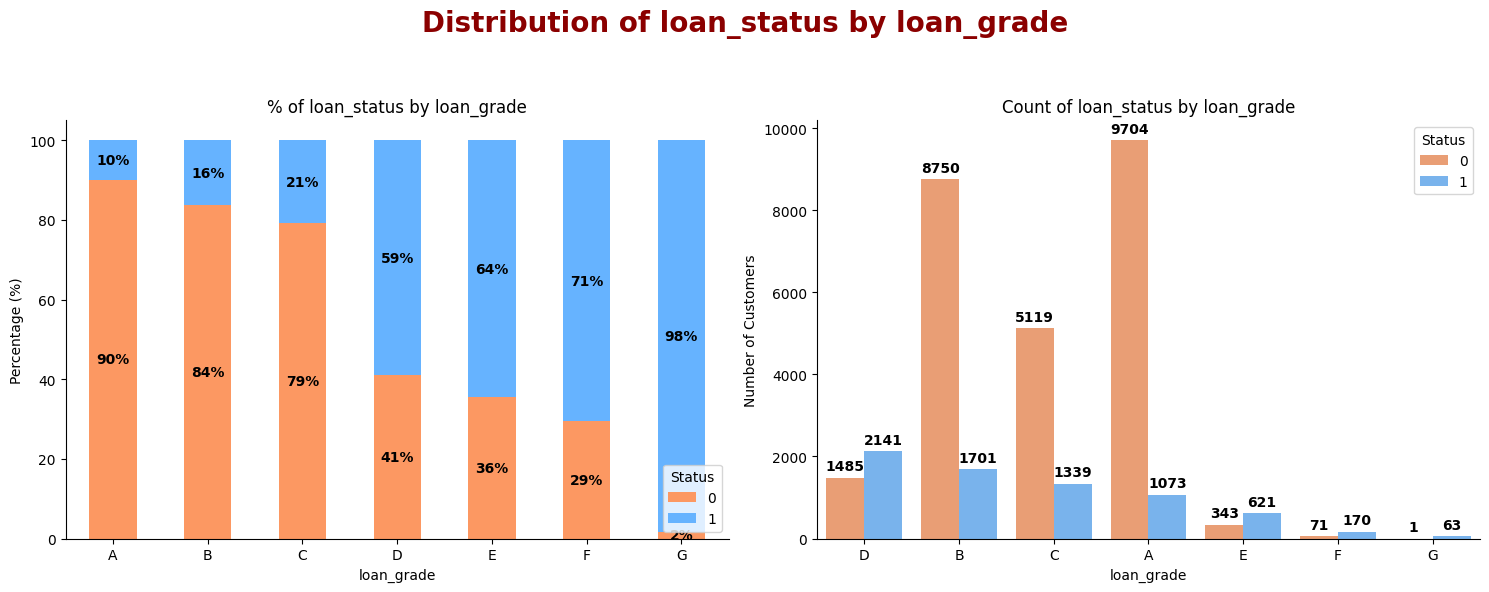


Chi-Square Test of Independence: 'loan_grade' và 'loan_status'
Giá trị Chi-square: 5609.184
Bậc tự do: 6
p-value: 0.000000
Kết quả: p-value < 0.05 -> Bác bỏ H0
Kết luận: Có mối liên hệ có ý nghĩa thống kê giữa 'loan_grade' và 'loan_status'.

Standardized Residuals:
loan_status      0      1
loan_grade               
A            13.92 -26.36
B             6.41 -12.13
C             0.98  -1.86
D           -25.35  48.00
E           -14.96  28.32
F            -8.55  16.19
G            -6.93  13.12


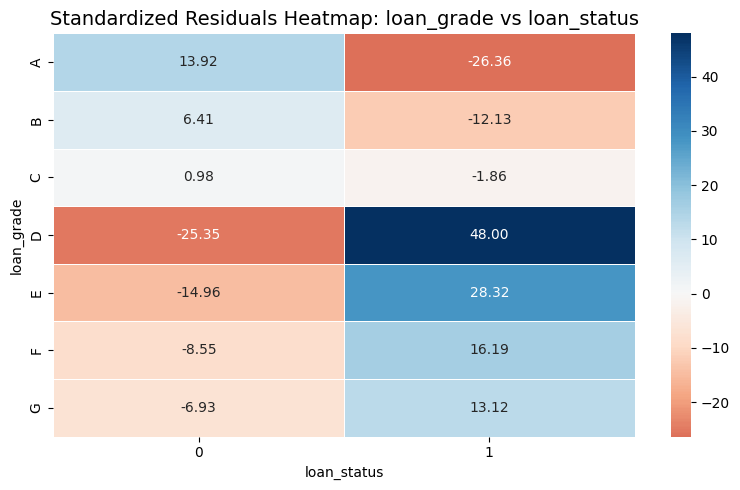

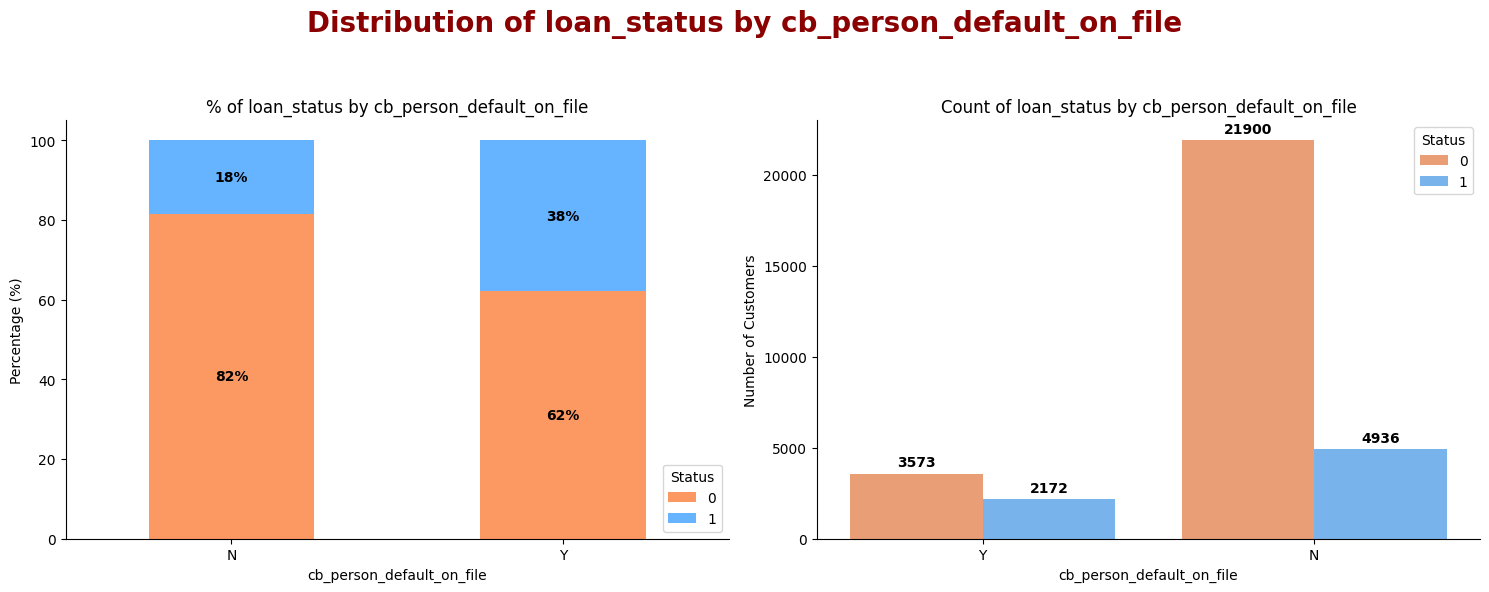


Chi-Square Test of Independence: 'cb_person_default_on_file' và 'loan_status'
Giá trị Chi-square: 1044.440
Bậc tự do: 1
p-value: 0.000000
Kết quả: p-value < 0.05 -> Bác bỏ H0
Kết luận: Có mối liên hệ có ý nghĩa thống kê giữa 'cb_person_default_on_file' và 'loan_status'.

Standardized Residuals:
loan_status                    0      1
cb_person_default_on_file              
N                           6.34 -12.01
Y                         -13.71  25.95


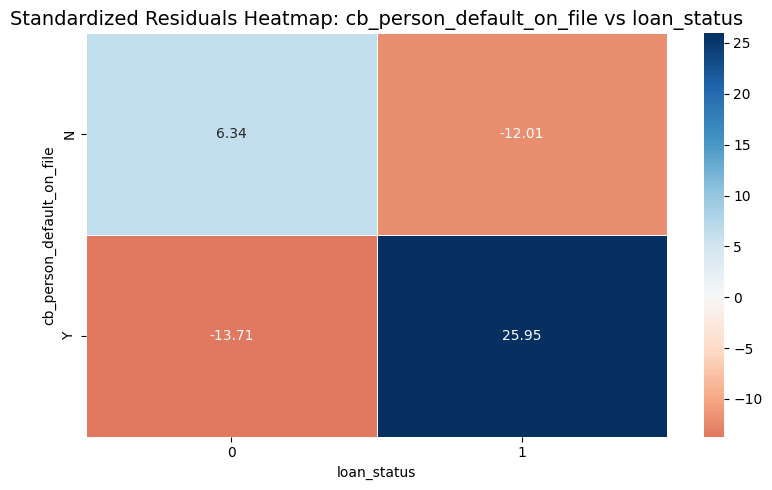

In [12]:
# BIỂU ĐỒ PHÂN PHỐI THEO TỶ LỆ % 

def bivariate_percent_plot(cat, df, figsize=(15, 6), order=None):
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f"Distribution of loan_status by {cat}", fontsize=20, fontweight="bold", 
                 color="darkred")
    # BIỂU ĐỒ 1
    grouped = df.groupby([cat, "loan_status"]).size().unstack(fill_value=0)
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100
    if order is not None:
        percentages = percentages.loc[order]

    percentages.plot(kind="bar", stacked=True, ax=ax[0], color=["#fc9862","#66b3ff"])
    ax[0].tick_params(axis="x", rotation=0)
    if cat == "loan_intent":
        ax[0].tick_params(axis="x", rotation=45)

    # Ghi nhãn % vào giữa các đoạn cột
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt='%.0f%%', label_type="center", weight="bold")

    ax[0].set_title(f"% of loan_status by {cat}")
    ax[0].set_ylabel("Percentage (%)")
    ax[0].legend(title="Status", loc="lower right")

    # BIỂU ĐỒ 2
    sns.countplot(data=df, x=cat, hue="loan_status", ax=ax[1], 
                  order=order, palette=["#fc9862","#66b3ff"])
    if cat == "loan_intent":
        ax[1].tick_params(axis="x", rotation=45)
    # Ghi số lượng cụ thể lên đầu cột
    for container in ax[1].containers:
        ax[1].bar_label(container, padding=3, weight="bold")

    ax[1].set_title(f"Count of loan_status by {cat}")
    ax[1].set_ylabel("Number of Customers")
    ax[1].legend(title="Status")

    sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# KIỂM ĐỊNH CHI-SQUARE
    cal_ChiSquare(cat, target_feature="loan_status", df=df, show_residuals=True)

for cat in cat_features:
    bivariate_percent_plot(cat=cat, df=df, figsize=(15, 6), order=None)

 <span style="color:white; font-size:20px;"><b>Nhận xét</b></span>

* **`person_home_ownership`**: Khách hàng thuê nhà (RENT) có tỷ lệ vỡ nợ cao nhất (~32%), trong khi nhóm sở hữu nhà (OWN) có tỷ lệ thấp nhất (~7%), cho thấy tình trạng sở hữu nhà là một yếu tố phản ánh rủi ro tín dụng khá mạnh.

* **`loan_intent`**: Mục đích vay vốn có liên hệ rõ rệt với rủi ro vỡ nợ. Các khoản vay để hợp nhất nợ (DEBTCONSOLIDATION) và chi phí y tế (MEDICAL) có tỷ lệ vỡ nợ cao hơn, trong khi vay cho giáo dục (EDUCATION) và khởi nghiệp (VENTURE) có mức rủi ro thấp hơn.

* **`loan_grade`**: Đây là biến ảnh hưởng mạnh nhất đến rủi ro tín dụng. Tỷ lệ vỡ nợ tăng rất mạnh từ nhóm A (~10%) lên đến G (~98%), cho thấy hệ thống xếp hạng tín dụng phản ánh rất tốt khả năng trả nợ của khách hàng.

* **`cb_person_default_on_file`**: Khách hàng từng có lịch sử vỡ nợ (Y) có tỷ lệ vỡ nợ cao hơn đáng kể (~38%) so với nhóm chưa từng vỡ nợ (~18%), cho thấy lịch sử tín dụng là yếu tố dự báo quan trọng.

In [13]:
# KIỂM ĐỊNH PHÂN PHỐI CHUẨN (NORMALITY TEST) VÀ KIỂM ĐỊNH MANN-WHITNEY U

def cal_normaltest(cat_feature, num_feature, df):
    print(f"\nNormality test for {num_feature} by {cat_feature}")

    for group in df[cat_feature].unique():
        data = df.loc[df[cat_feature] == group, num_feature].dropna()

        if len(data) < 8:
            print(f"Group {group}: không đủ dữ liệu để chạy normaltest")
            continue
        stat, p_value = normaltest(data)

        print(f"Group {group} (n={len(data)})")
        print(f"Statistic: {stat:.4f}")
        print(f"P-value: {p_value:.4f}")

        if p_value < 0.05:
            print("=> Dữ liệu không tuân theo phân phối chuẩn\n")
        else:
            print("=> Chưa đủ bằng chứng nói dữ liệu không phân phối chuẩn\n")


def cal_mannwhitneyu(dataframe, categorical_feature, num_feature):
    groups = dataframe[categorical_feature].unique()

    if len(groups) != 2:
        print("Mann-Whitney U chỉ dùng khi target có đúng 2 nhóm.")
        return
    group_1 = dataframe.loc[dataframe[categorical_feature] == groups[0], num_feature].dropna()
    group_2 = dataframe.loc[dataframe[categorical_feature] == groups[1], num_feature].dropna()

    stat, p_value = mannwhitneyu(group_1, group_2, alternative="two-sided")

    print(f"\nMann-Whitney U test for {num_feature} by {categorical_feature}")
    print(f"Statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("=> Hai nhóm khác biệt có ý nghĩa thống kê")
    else:
        print("=> Chưa đủ bằng chứng nói hai nhóm khác biệt")



Summary for person_age 

Overall Mean   : 27.73
Overall Median : 26.00
Overall Std    : 6.35


,loan_status,Count,Mean,Median,Std
0,0,25473,27.807129,26.000000,6.369669
1,1,7108,27.474676,26.000000,6.263642



Normality test for person_age by loan_status
Group 1 (n=7108)
Statistic: 2935.7887
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn

Group 0 (n=25473)
Statistic: 16932.9326
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn


Mann-Whitney U test for person_age by loan_status
Statistic: 86323515.0000
P-value: 0.0000
=> Hai nhóm khác biệt có ý nghĩa thống kê


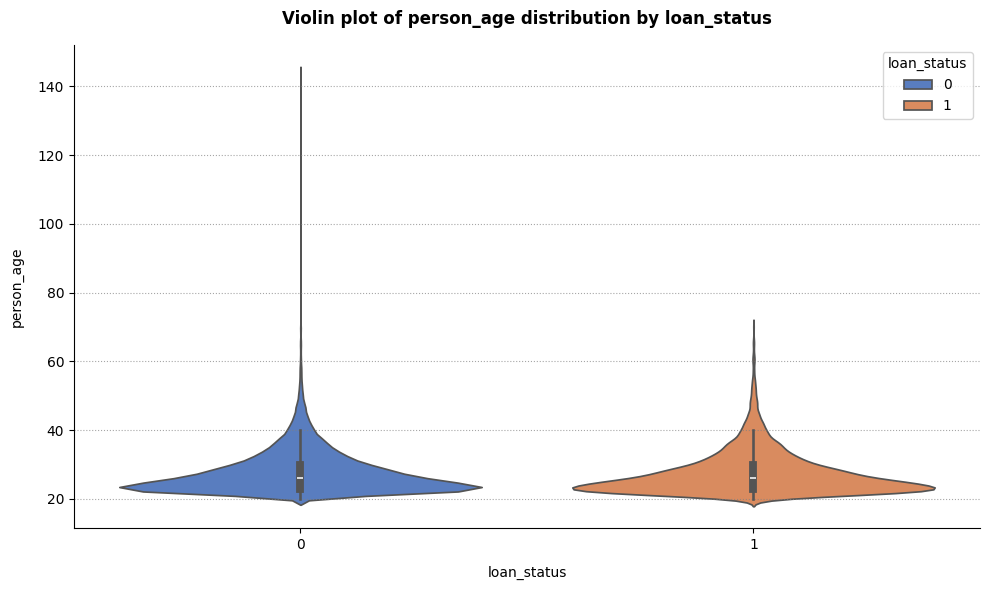


Summary for person_income 

Overall Mean   : 66074.85
Overall Median : 55000.00
Overall Std    : 61983.12


,loan_status,Count,Mean,Median,Std
0,0,25473,70804.361559,60000.000000,66568.802606
1,1,7108,49125.652223,41498.000000,36907.376527



Normality test for person_income by loan_status
Group 1 (n=7108)
Statistic: 7874.2722
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn

Group 0 (n=25473)
Statistic: 69485.8726
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn


Mann-Whitney U test for person_income by loan_status
Statistic: 56093141.5000
P-value: 0.0000
=> Hai nhóm khác biệt có ý nghĩa thống kê


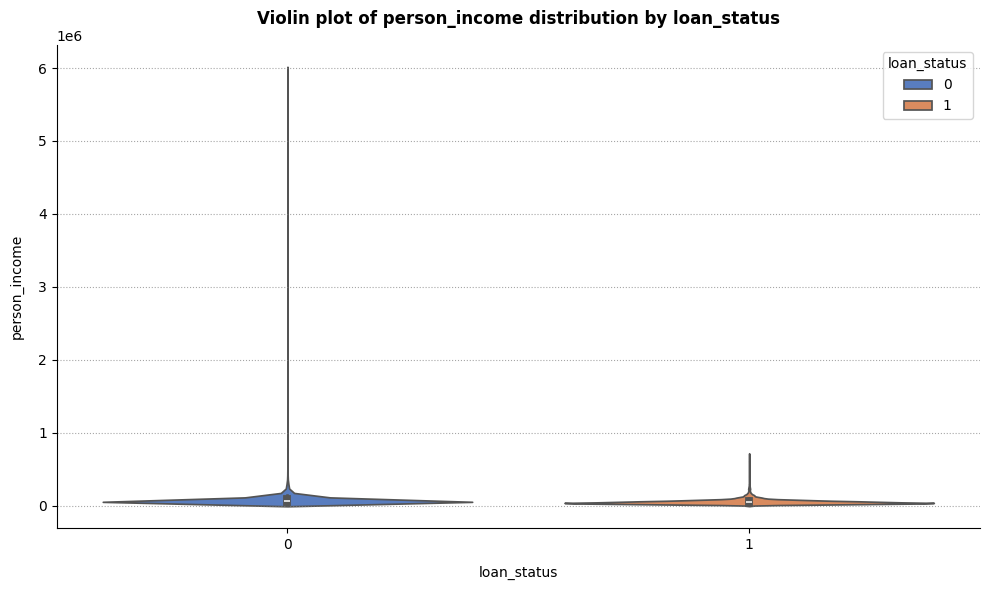


Summary for person_emp_length 

Overall Mean   : 4.79
Overall Median : 4.00
Overall Std    : 4.14


,loan_status,Count,Mean,Median,Std
0,0,24860,4.968745,4.000000,4.129022
1,1,6826,4.137562,3.000000,4.126956



Normality test for person_emp_length by loan_status
Group 1 (n=6826)
Statistic: 7279.9022
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn

Group 0 (n=24860)
Statistic: 14588.4415
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn


Mann-Whitney U test for person_emp_length by loan_status
Statistic: 73273846.5000
P-value: 0.0000
=> Hai nhóm khác biệt có ý nghĩa thống kê


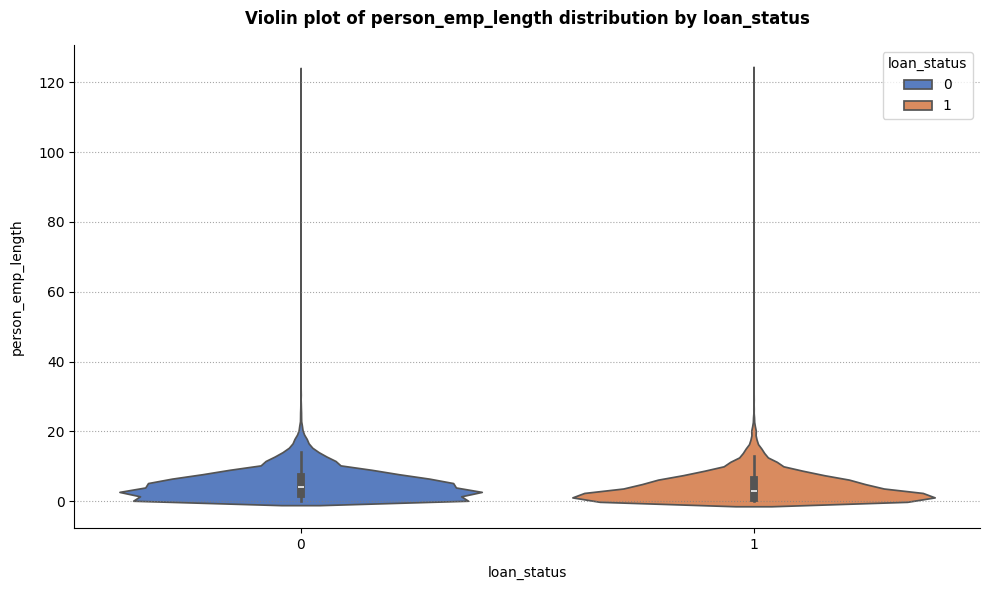


Summary for loan_amnt 

Overall Mean   : 9589.37
Overall Median : 8000.00
Overall Std    : 6322.09


,loan_status,Count,Mean,Median,Std
0,0,25473,9237.464178,8000.000000,6026.375457
1,1,7108,10850.502954,9600.000000,7143.345344



Normality test for loan_amnt by loan_status
Group 1 (n=7108)
Statistic: 740.2093
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn

Group 0 (n=25473)
Statistic: 5326.9126
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn


Mann-Whitney U test for loan_amnt by loan_status
Statistic: 101157877.5000
P-value: 0.0000
=> Hai nhóm khác biệt có ý nghĩa thống kê


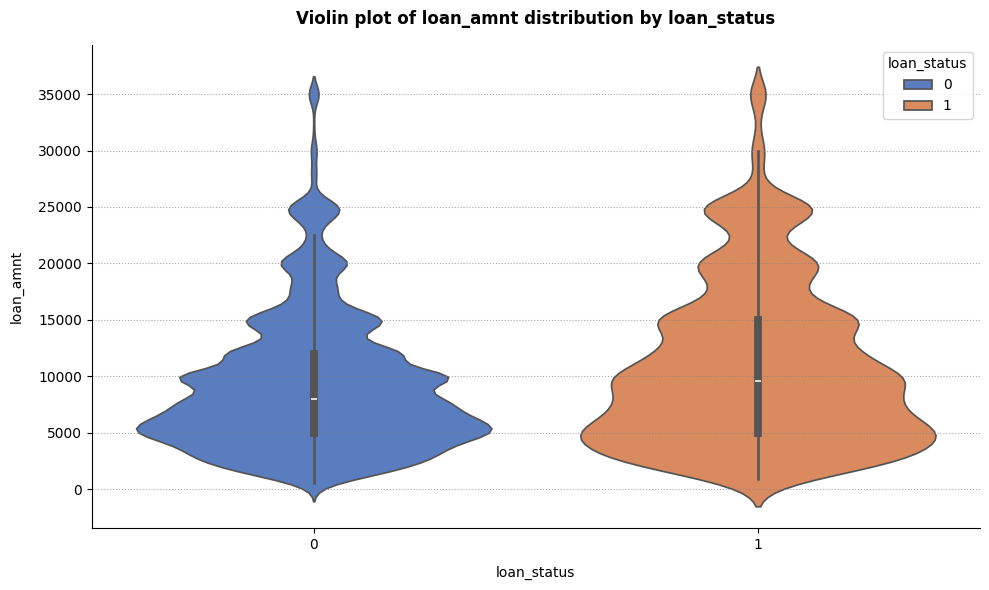


Summary for loan_int_rate 

Overall Mean   : 11.01
Overall Median : 10.99
Overall Std    : 3.24


,loan_status,Count,Mean,Median,Std
0,0,23001,10.435999,10.590000,2.982190
1,1,6464,13.060207,13.490000,3.293167



Normality test for loan_int_rate by loan_status
Group 1 (n=6464)
Statistic: 209.9283
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn

Group 0 (n=23001)
Statistic: 1321.1557
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn


Mann-Whitney U test for loan_int_rate by loan_status
Statistic: 107532120.5000
P-value: 0.0000
=> Hai nhóm khác biệt có ý nghĩa thống kê


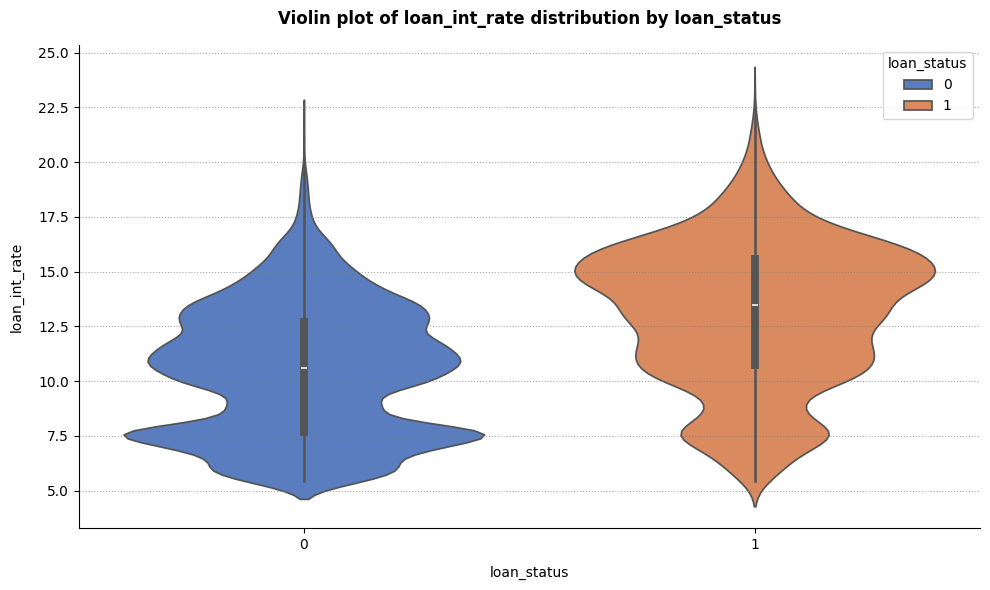


Summary for loan_percent_income 

Overall Mean   : 0.17
Overall Median : 0.15
Overall Std    : 0.11


,loan_status,Count,Mean,Median,Std
0,0,25473,0.148805,0.130000,0.087252
1,1,7108,0.246889,0.240000,0.132148



Normality test for loan_percent_income by loan_status
Group 1 (n=7108)
Statistic: 242.8413
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn

Group 0 (n=25473)
Statistic: 4090.7481
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn


Mann-Whitney U test for loan_percent_income by loan_status
Statistic: 130515403.5000
P-value: 0.0000
=> Hai nhóm khác biệt có ý nghĩa thống kê


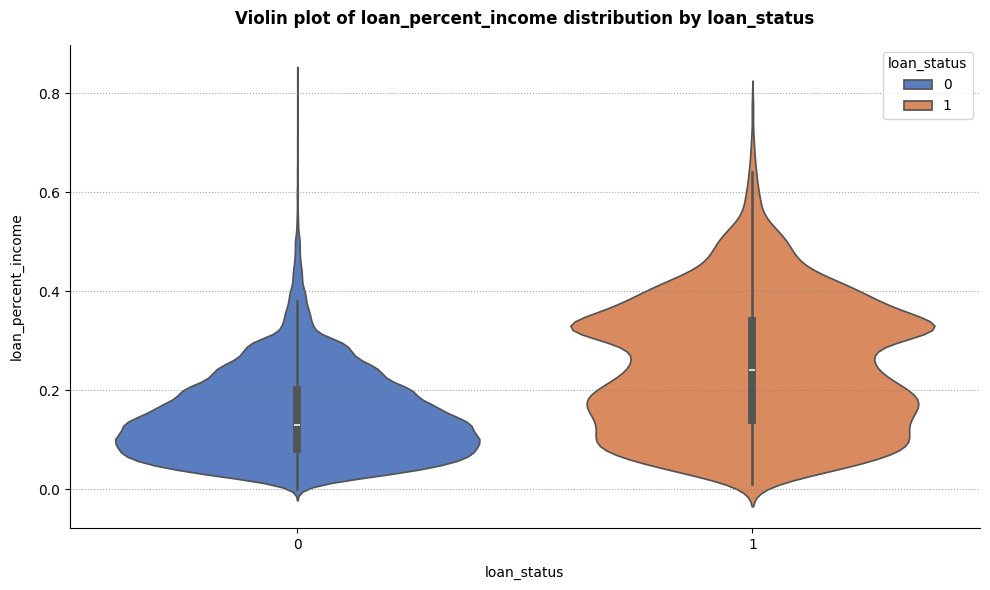


Summary for cb_person_cred_hist_length 

Overall Mean   : 5.80
Overall Median : 4.00
Overall Std    : 4.06


,loan_status,Count,Mean,Median,Std
0,0,25473,5.837475,4.000000,4.040900
1,1,7108,5.685003,4.000000,4.103208



Normality test for cb_person_cred_hist_length by loan_status
Group 1 (n=7108)
Statistic: 2610.6514
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn

Group 0 (n=25473)
Statistic: 7897.3810
P-value: 0.0000
=> Dữ liệu không tuân theo phân phối chuẩn


Mann-Whitney U test for cb_person_cred_hist_length by loan_status
Statistic: 87550955.5000
P-value: 0.0000
=> Hai nhóm khác biệt có ý nghĩa thống kê


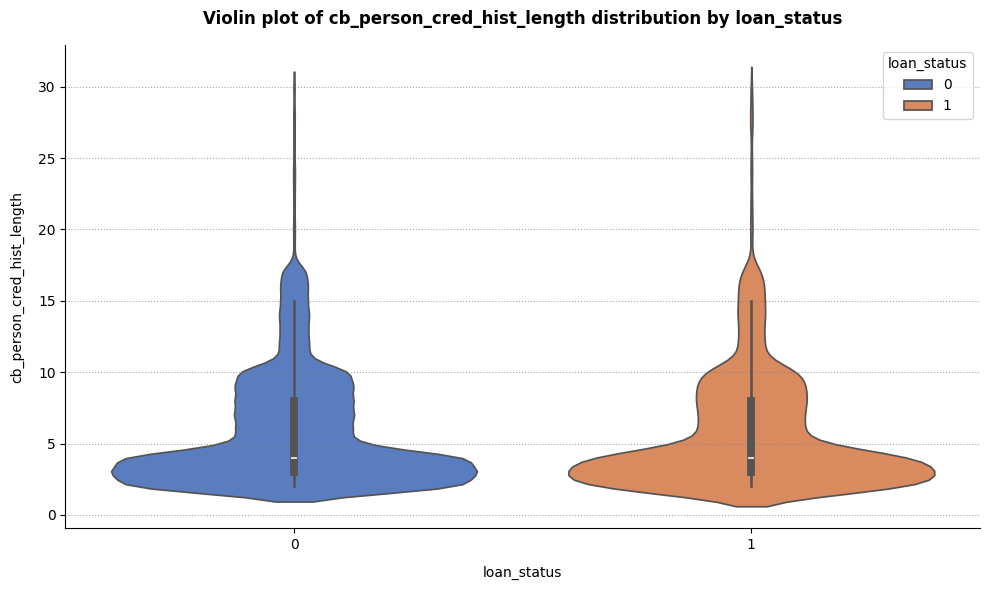

In [14]:
def perform_statical_testing(feature, df, target_feature="loan_status"):
    cal_normaltest(cat_feature=target_feature, num_feature=feature, df=df)
    cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution_by_loan_status (feature, df = df, target_feature = "loan_status"):
    
    df_summary_feature = df.groupby(by = target_feature, as_index= False)\
    .agg (Count = (feature, "count"), Mean = (feature, "mean"),
        Median = (feature, "median"),Std = (feature, "std"))
    
    print(f"\nSummary for {feature} \n")
    print(f"Overall Mean   : {df[feature].mean():.2f}")
    print(f"Overall Median : {df[feature].median():.2f}")
    print(f"Overall Std    : {df[feature].std():.2f}")

    display(df_summary_feature.style.background_gradient(cmap="Oranges").set_table_attributes('style="width:75%; margin:auto;"'))

    perform_statical_testing(feature=feature, df=df, target_feature=target_feature)

    # BIỂU ĐỒ VIOLIN
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature,
                   palette=sns.color_palette("muted", n_colors=len(df[target_feature].unique())), ax=ax)
    ax.set_title(f"Violin plot of {feature} distribution by {target_feature}", 
                 pad=15, weight = "bold")
    ax.set_xlabel(target_feature, labelpad=10)
    ax.set_ylabel(feature, labelpad=10)
    plt.grid(axis="y", color="gray", linestyle=":", alpha=0.7)
    sns.despine(left=False, bottom=False, ax=ax)
    plt.tight_layout()
    plt.show()
    
for feature in num_features:
    plot_numerical_distribution_by_loan_status(feature=feature, df=df, target_feature="loan_status")


<span style="color:white; font-size:20px;"><b>Nhận xét</b></span>

* `person_age`: Khách hàng vay vốn chủ yếu là người trẻ và có độ tuổi tương đồng nhau, đa số người vay tập trung quanh mức **26-27 tuổi** và biểu đồ Violin cho thấy cấu trúc độ tuổi của hai nhóm nợ xấu **gần như giống hệt nhau**, chứng tỏ độ tuổi không phải là yếu tố quyết định để xác định một khách hàng có vỡ nợ hay không. Tuy nhiên, kết quả kiểm định Mann-Whitney U vẫn cho thấy **có sự khác biệt về phân phối giữa hai nhóm có ý nghĩa thống kê** (P-value = 0.0000), gợi ý rằng độ tuổi vẫn mang một lượng thông tin nhỏ nhất định mà mô hình có thể khai thác khi kết hợp với các biến số khác.

* `person_income`: Khách hàng không vỡ nợ có thu nhập **cao hơn đáng kể** với mức trung vị là 60,000 so với 41,000 của nhóm vỡ nợ, cho thấy thu nhập là biến quan trọng trong đánh giá rủi ro tín dụng. Điều này thống nhất với kết quả kiểm định Mann-Whitney U (P-value = 0.0000), khẳng định thu nhập là một **yếu tố dự báo mạnh mẽ** có khả năng phân biệt rõ ràng giữa 2 nhóm khách hàng.

* `person_emp_length`: Nhóm khách hàng nợ xấu (loan_status = 1) có **thâm niên làm việc ít hơn** với mức trung vị là 3 năm, thấp hơn so với mức 4 năm của nhóm không có nợ xấu. Biểu đồ Violin cho thấy cả hai nhóm thường có **thâm niên làm việc ngắn** (dưới 10 năm), nhưng nhóm nợ xấu có xu hướng **tập trung nhiều hơn ở các giá trị thấp** (0- 5năm). Kết quả kiểm định Mann-Whitney U (P-value = 0.0000) cho thấy sự khác biệt về thâm niên làm việc giữa hai nhóm là có ý nghĩa thống kê, cho thấy đây là một **yếu tố quan trọng** mà mô hình có thể sử dụng để phân loại rủi ro khách hàng.

* `loan_amnt`: Nhóm khách hàng nợ xấu (loan_status = 1) có xu hướng vay số tiền lớn hơn với mức trung vị là 9,600, cao hơn hẳn so với mức 8,000 của nhóm không nợ xấu. Biểu đồ Violin cũng cho thấy nhóm nợ xấu **tập trung nhiều hơn ở các phân khúc vay cao từ 15,000 đến 25,000**. Điều này thống nhất với kết quả kiểm định Mann-Whitney U (P-value = 0.0000), khẳng định số tiền vay là một **nhân tố quan trọng** có khả năng phân loại rủi ro khách hàng rõ rệt trong mô hình.

* `loan_int_rate`: Nhóm khách hàng nợ xấu phải **chịu mức lãi suất cao hơn rõ rệt** với trung vị là 13.49%, so với mức 10.59% của nhóm không nợ xấu. Biểu đồ Violin cho thấy **sự tách biệt rất lớn giữa hai nhóm**: trong khi nhóm 0 tập trung đông nhất ở vùng lãi suất thấp (khoảng 7.5% - 11%), thì nhóm 1 lại tập trung ở các mức lãi suất cao từ 12.5% đến trên 15%. Điều này hoàn toàn đồng nhất với kết quả kiểm định Mann-Whitney U (P-value = 0.0000), khẳng định **lãi suất là một trong những biến số quan trọng** phản ánh rủi ro vỡ nợ, **khi mức lãi suất càng cao thì áp lực trả nợ càng lớn dẫn đến khả năng nợ xấu càng gia tăng**.

* `loan_percent_income`: Nhóm khách hàng nợ xấu có tỷ lệ khoản vay trên thu nhập **cao hơn đáng kể** so với nhóm khách hàng không nợ xấu, với trung vị 0.24 so với 0.13 của nhóm không nợ xấu. Biểu đồ Violin cho thấy nhóm nợ xấu có xu hướng tập trung ở các giá trị cao (0.2 - 0.4), trong khi nhóm không nợ xấu chủ yếu tập trung ở các giá trị thấp hơn (dưới 0.2). Kết quả kiểm định Mann-Whitney U (P-value = 0.0000) khẳng định sự khác biệt về tỷ lệ khoản vay trên thu nhập giữa hai nhóm là có ý nghĩa thống kê, cho thấy đây là một **yếu tố dự báo quan trọng** mà mô hình có thể sử dụng để phân loại rủi ro khách hàng.

* `cb_person_cred_hist_length`: Lịch sử tín dụng giữa hai nhóm **gần như tương đương**, với mức trung vị đều là 4, nên khả năng phân biệt rủi ro không cao. Kết quả kiểm định Mann-Whitney U (P-value = 0.0000) cho thấy **có sự khác biệt về phân phối lịch sử tín dụng giữa hai nhóm** là có ý nghĩa thống kê, nhưng do mức độ khác biệt rất nhỏ nên biến này có thể không đóng vai trò quan trọng trong mô hình dự báo rủi ro tín dụng.


<h4 style="color:yellow;font-weight:bold;">
TIỀN XỬ LÝ DỮ LIỆU
</h4> 

<h4 style="color:green;font-weight:bold;font-size:18px;">
XỬ LÝ GIÁ TRỊ BỊ THIẾU
</h4>

In [15]:
# Xử lý giá trị bị thiếu

df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df.groupby('loan_status')['loan_int_rate'].transform('median'))
assert df['loan_int_rate'].isnull().sum() == 0, "Vẫn còn giá trị thiếu ở cột loan_int_rate!"
print("Hoàn tất xử lý giá trị thiếu.")

df['person_emp_length'] = df['person_emp_length'].fillna(
    df.groupby('loan_status')['person_emp_length'].transform('median'))
assert df['person_emp_length'].isnull().sum() == 0, "Vẫn còn giá trị thiếu ở cột person_emp_length!"
print("Hoàn tất xử lý giá trị thiếu.")

Hoàn tất xử lý giá trị thiếu.
Hoàn tất xử lý giá trị thiếu.


<h4 style="color:green;font-weight:bold;font-size:18px;">
XỬ LÝ DÒNG BỊ TRÙNG LẶP
</h4>

In [16]:
# Xóa các dòng trùng lặp, chỉ giữ lại bản ghi đầu tiên
df = df.drop_duplicates(keep='first')

# Kiểm tra lại xem còn dòng nào không
print(f"Số dòng còn lại sau khi xóa trùng: {df.shape[0]}")
print(f"Số dòng trùng còn lại: {df.duplicated().sum()}")

Số dòng còn lại sau khi xóa trùng: 32416
Số dòng trùng còn lại: 0


<h4 style="color:green;font-weight:bold;font-size:18px;">
XỬ LÝ GIÁ TRỊ NGOẠI LAI
</h4>

In [17]:
# Xóa các tuổi bất hợp lý nếu có
df = df[df["person_age"] <= 100] # Giả sử tuổi tối đa là 100

# Xóa số năm làm việc bất hợp lý nếu có
df = df[df["person_emp_length"] <= df["person_age"] - 14] # Giả sử người bắt đầu làm việc từ 14 tuổi trở lên

for col in ["person_income", "loan_amnt"]:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)
print(f"Số dòng còn lại sau khi xóa oulier: {df.shape[0]}")
print(df.head(5))

Số dòng còn lại sau khi xóa oulier: 32409
   person_age  person_income person_home_ownership  person_emp_length  \
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   
5          21           9900                   OWN                2.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
1   EDUCATION          B     1000.0          11.14            0   
2     MEDICAL          C     5500.0          12.87            1   
3     MEDICAL          C    29792.0          15.23            1   
4     MEDICAL          C    29792.0          14.27            1   
5     VENTURE          A     2500.0           7.14            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
1                 0.10               

<h4 style="color:green;font-weight:bold;font-size:18px;">
XỬ LÝ DỮ LIỆU LỆCH
</h4>

In [18]:
df_cleaned = df.copy()
# Khởi tạo bộ biến đổi Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')

# Danh sách các cột có độ lệch cao
skewed_features = ['person_age', 'person_income', 'cb_person_cred_hist_length', 
    'person_emp_length', 'loan_amnt', 'loan_percent_income']

df[skewed_features] = pt.fit_transform(df[skewed_features])

print("--- KIỂM TRA LẠI ĐỘ LỆCH SAU KHI BIẾN ĐỔI ---")
print(df[skewed_features].skew())


--- KIỂM TRA LẠI ĐỘ LỆCH SAU KHI BIẾN ĐỔI ---
person_age                    0.157902
person_income                 0.002098
cb_person_cred_hist_length    0.095099
person_emp_length            -0.043793
loan_amnt                    -0.025988
loan_percent_income           0.089345
dtype: float64


<span style="color:white; font-size:20px;"><b>Nhận xét</b></span>

**Xử lý giá trị bị thiếu**

Dựa trên kết quả kiểm tra chất lượng dữ liệu, chúng ta đã phát hiện ra rằng có hai biến số quan trọng có giá trị bị thiếu là `loan_int_rate` và `person_emp_length`. Để khắc phục vấn đề này, phương pháp **Imputation bằng giá trị trung vị theo nhóm** (Group-based Median Imputation) đã được áp dụng. Thay vì sử dụng giá trị trung bình dễ bị ảnh hưởng bởi các sai số ngoại lệ, chúng ta sử dụng **trung vị của từng nhóm loan_status để lấp đầy các khoảng trống**. Cách tiếp cận này giúp duy trì sự phân bố tự nhiên của dữ liệu và đảm bảo rằng các giá trị bị thiếu được thay thế bằng những giá trị đại diện cho nhóm tương ứng, từ đó cải thiện hiệu suất của các mô hình học máy trong việc dự báo rủi ro tín dụng.

**Xử lý dòng bị trùng lặp**

Dựa trên kết quả kiểm tra chất lượng dữ liệu, chúng ta đã phát hiện ra rằng có 165 dòng bị trùng lặp hoàn toàn trong bộ dữ liệu. Để đảm bảo tính chính xác và độ tin cậy của phân tích, chúng ta đã **loại bỏ những dòng này khỏi bộ dữ liệu**trước khi tiến hành các bước xử lý tiếp theo. Việc loại bỏ các dòng trùng lặp giúp giảm thiểu sự thiên lệch và đảm bảo rằng mô hình học máy sẽ không bị ảnh hưởng bởi các bản ghi lặp lại, từ đó cải thiện hiệu suất dự báo rủi ro tín dụng.

**Xử lý giá trị ngoại lai**

Dựa trên kết quả kiểm tra chất lượng dữ liệu, chúng ta đã phát hiện ra rằng có một số lượng lớn giá trị ngoại lai (outliers) xuất hiện ở nhiều biến số trong bộ dữ liệu. Do đó không thể loại bỏ trực tiếp số lượng lớn giá trị này vì sẽ làm sai lệch dữ liệu. Do đó trước hết chúng ta sẽ xóa bỏ những giá trị bất hợp lý có thể nhìn thấy bằng mắt thường (ví dụ: tuổi 144, thâm niên làm việc 123 năm) và sau đó áp dụng kỹ thuật **Winsorization** để giới hạn các giá trị ngoại lai ở mức phần trăm nhất định (ví dụ: 1% và 99%). Phương pháp này giúp giảm ảnh hưởng của các giá trị cực đoan mà không loại bỏ hoàn toàn chúng, từ đó duy trì sự đa dạng của dữ liệu và cải thiện hiệu suất của các mô hình học máy trong việc dự báo rủi ro tín dụng.

**Xử lý dữ liệu lệch**

Dựa trên kết quả kiểm tra chất lượng dữ liệu, chúng ta đã phát hiện ra rằng phần lớn các biến số trong bộ dữ liệu có phân phối lệch phải mạnh mẽ, điều này có thể ảnh hưởng tiêu cực đến hiệu suất của các mô hình học máy, đặc biệt là những mô hình nhạy cảm với phân phối dữ liệu như Logistic Regression. Do đó, chúng ta đã áp dụng kỹ thuật **Yeo-Johnson Transformation** để nắn chỉnh các biến số này về gần với phân phối chuẩn hơn. Phương pháp này giúp cải thiện khả năng học từ dữ liệu và tăng độ chính xác của các mô hình dự báo rủi ro tín dụng.

<span style="color:blue; font-size:16px;">Ở bước này, do phương pháp Yeo-Johnson chuyển đổi dữ liệu về thang đo chung nên có thể làm thay đổi dữ liệu ban đầu, do đó chúng ta giả sử `df_cleaned` là bộ dữ liệu chưa được áp dụng Yeo-Johnson để giữ lại số liệu gốc phục vụ cho các phân tích sau này.</span>

#### MÃ HÓA DỮ LIỆU 

In [19]:
df_encoded = df.copy()

# Mã hóa theo thứ tự
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_encoded['loan_grade'] = df_encoded['loan_grade'].map(grade_map)
# Mã hóa nhị phân
default_map = {'Y': 1, 'N': 0}
df_encoded['cb_person_default_on_file'] = df_encoded['cb_person_default_on_file'].map(default_map)
# Mã hóa one-hot cho 2 cột còn lại
cat_to_onehot = ['person_home_ownership', 'loan_intent']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_parts = encoder.fit_transform(df_encoded[cat_to_onehot])
encoded_df = pd.DataFrame(encoded_parts, 
                          columns=encoder.get_feature_names_out(cat_to_onehot),
                          index=df_encoded.index)

# Ghép lại vào df gốc và bỏ đi 2 cột chữ cũ
df_final = pd.concat([df_encoded.drop(columns=cat_to_onehot), encoded_df], axis=1)

print("--- DỮ LIỆU SAU KHI ĐỊNH LƯỢNG HÓA HOÀN TOÀN ---")
print(df_final.shape)
print(df_final.head())

--- DỮ LIỆU SAU KHI ĐỊNH LƯỢNG HÓA HOÀN TOÀN ---
(32409, 20)
   person_age  person_income  person_emp_length  loan_grade  loan_amnt  \
1   -1.802822      -3.067670           0.313936           2  -2.380563   
2   -0.290018      -3.067670          -1.045239           3  -0.542722   
3   -0.936010       0.294546           0.059436           3   2.245687   
4   -0.590314      -0.043381           0.927141           3   2.245687   
5   -1.802822      -3.016048          -0.590082           1  -1.490704   

   loan_int_rate  loan_status  loan_percent_income  cb_person_default_on_file  \
1          11.14            0            -0.619445                          0   
2          12.87            1             2.321668                          0   
3          15.23            1             2.216969                          0   
4          14.27            1             2.270957                          1   
5           7.14            1             0.913436                          0   

   cb_p

<span style="color:white; font-size:20px;"><b>Nhận xét</b></span>

Bước này được gọi là **Mã hóa dữ liệu danh mục (Categorical Encoding)**, giúp chuyển đổi các biến định tính (dạng chữ) sang định dạng số để máy tính có thể tính toán được. Quy trình thực hiện cụ thể như sau:

* **Mã hóa thứ tự (Ordinal Encoding):** Áp dụng cho biến `loan_grade` (xếp hạng khoản vay) bằng cách gán các con số từ 1 đến 7. Việc này giúp giữ lại ý nghĩa về cấp độ: hạng A (1) tốt hơn hạng B (2), và tương tự cho các hạng sau.

* **Mã hóa nhị phân (Binary Encoding):** Áp dụng cho biến `cb_person_default_on_file` để chuyển trạng thái "Có/Không" (Y/N) về "1/0", giúp mô hình dễ dàng nhận diện lịch sử nợ xấu của khách hàng.

* **Mã hóa One-Hot (One-Hot Encoding):** Áp dụng cho các biến không có tính thứ tự như hình thức sở hữu nhà (`person_home_ownership`) và mục đích vay (`loan_intent`). Mỗi giá trị chữ sẽ được tách thành một cột riêng chứa giá trị 0 hoặc 1, tránh việc mô hình hiểu nhầm các mục đích vay này có sự phân cấp cao thấp.


<h4 style="color:yellow;font-weight:bold;">
XÂY DỰNG MÔ HÌNH
</h4>

<h4 style="color:green;font-weight:bold;font-size:18px;">
CHIA DỮ LIỆU THÀNH TẬP HUẤN LUYỆN VÀ KIỂM TRA
</h4>

In [20]:
# Chia tập dữ liệu thành tập Train/Test với tỷ lệ 70/30
X = df_final.drop(columns=['loan_status']) 
y = df_final['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cân bằng dữ liệu bằng SMOTE (Chỉ áp dụng trên tập Train)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Kích thước tập Train sau SMOTE: {X_train_res.shape}")
unique_res, counts_res = np.unique(y_train_res, return_counts=True)
print(dict(zip(unique_res, counts_res)))


Kích thước tập Train sau SMOTE: (35448, 19)
{np.int64(0): np.int64(17724), np.int64(1): np.int64(17724)}


<h4 style="color:green;font-weight:bold;font-size:18px;">
PHÂN CỤM DỮ LIỆU VỚI K-MEANS
</h4>

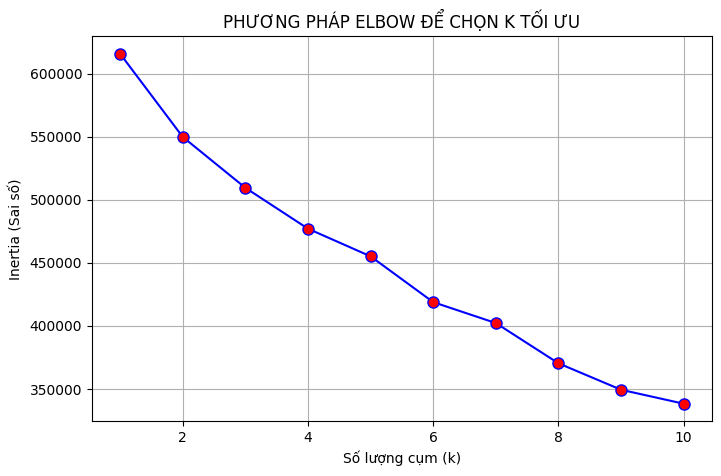

In [21]:
# CHUẨN HÓA DỮ LIỆU CHO PHÂN CỤM

X_cluster = df_final.drop(columns=['loan_status'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# TÌM SỐ CỤM TỐI ƯU (PHƯƠNG PHÁP ELBOW)

inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', markerfacecolor='red', markersize=8)
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Inertia (Sai số)')
plt.title('PHƯƠNG PHÁP ELBOW ĐỂ CHỌN K TỐI ƯU')
plt.grid(True)
plt.show()



Dựa trên phương pháp Elbow , số lượng cụm **k=3** được lựa chọn vì đây là điểm nơi tốc độ giảm của sai số (Inertia) bắt đầu chững lại rõ rệt. Tại giá trị này, mô hình đạt được sự cân bằng tối ưu giữa việc giảm thiểu biến thiên nội cụm và duy trì tính đơn giản, giúp phân loại các nhóm khách hàng một cách hiệu quả mà không gây ra hiện tượng quá mức (overfitting) như khi tiếp tục tăng số cụm lên cao hơn.

In [22]:
# PHÂN CỤM VỚI K=3
# BIẾN ĐỊNH LƯỢNG 

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cleaned['cluster'] = clusters

num_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income'] # Biến định lượng gốc
cluster_summary = df_cleaned.groupby('cluster')[num_features].mean()
cluster_counts = df_cleaned.groupby('cluster').size().rename('count')
loan_status_rate = df_cleaned.groupby('cluster')['loan_status'].mean().rename('loan_status_rate')

summary = cluster_summary.join(cluster_counts).join(loan_status_rate)

fmt = {
    'person_age': '{:.1f}',
    'person_income': '{:,.0f}',
    'person_emp_length': '{:.1f}',
    'loan_amnt': '{:,.0f}',
    'loan_int_rate': '{:.2f}%',
    'loan_percent_income': '{:.2f}%',
    'count': '{:,}',
    'loan_status_rate': '{:.2%}'
}

styled = (summary.style
          .format(fmt)
          .bar(subset=['loan_status_rate'], color='#ff6b6b')
          .background_gradient(subset=num_features, cmap='YlGnBu')
          .set_caption("BẢNG TÓM TẮT PHÂN CỤM: ĐẶC TRƯNG VÀ TỈ LỆ RỦI RO")
          .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '16px')]}])
         )

styled



,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,count,loan_status_rate
cluster,,,,,,,,
0,27.8,"62,953",4.4,"10,590",14.72%,0.19%,"7,565",44.27%
1,27.4,"53,613",4.0,"8,536",10.17%,0.18%,"13,881",20.92%
2,28.0,"78,866",5.9,"10,144",9.58%,0.15%,"10,963",7.62%


<span style="color:white; font-size:20px;"><b>Nhận xét</b></span>

Bảng tóm tắt được trình bày theo dữ liệu df_cleaned (dữ liệu chưa chuẩn hóa) để giữ lại ý nghĩa thực tế của các biến số, giúp chúng ta hiểu rõ hơn về đặc điểm của từng cụm khách hàng dựa trên các chỉ số tài chính và rủi ro tín dụng.

* **Cụm 0 - Nhóm rủi ro cao**: Đây là nhóm có tỉ lệ nợ xấu cao nhất (44.27%). Khách hàng trong nhóm này thường chịu mức lãi suất vay rất cao (14.72%) và có tỉ trọng khoản vay trên thu nhập lớn nhất (19%), mặc dù mức thu nhập và thâm niên làm việc chỉ ở mức trung bình.

* **Cụm 1 - Nhóm rủi ro trung bình**: Nhóm chiếm số lượng đông nhất (13,881 khách hàng) với tỉ lệ nợ xấu khoảng 20.92%. Đây là phân khúc khách hàng có thu nhập thấp nhất (53,613) và khoản vay cũng thấp nhất, đại diện cho nhóm khách hàng phổ thông với nhu cầu vay nhỏ lẻ.

* **Cụm 2 - Nhóm an toàn (VIP)**: Đây là nhóm khách hàng lý tưởng với tỉ lệ nợ xấu thấp nhất (7.62%). Nhóm này sở hữu thu nhập cao nhất (78,866), thâm niên làm việc lâu dài nhất (5.9 năm) và được hưởng mức lãi suất ưu đãi nhất (9.58%).

**Tổng kết:** Mô hình phân cụm đã tách biệt thành công các phân khúc khách hàng dựa trên năng lực tài chính, giúp tổ chức tín dụng có thể đưa ra các chính sách lãi suất và phê duyệt khác biệt cho từng nhóm nhằm tối ưu hóa lợi nhuận và giảm thiểu rủi ro nợ xấu.

In [23]:
# BIẾN ĐỊNH TÍNH (ĐÃ MÃ HÓA ONE-HOT VÀ NHỊ PHÂN)
cat_features = [col for col in df_final.columns if any(prefix in col for prefix in 
               ['person_home_ownership_', 'loan_intent_', 'cb_person_default_on_file'])]
df_final['cluster'] = clusters
cluster_cat_summary = df_final.groupby('cluster')[cat_features].mean()
cluster_cat_summary = cluster_cat_summary.T

styled_cat = (cluster_cat_summary.style
              .format('{:.1%}') # Hiển thị dưới dạng phần trăm
              .background_gradient(cmap='Reds', axis=1) # Tô màu theo dòng để xem đặc điểm đó tập trung ở cụm nào
              .set_caption("PHÂN TÍCH ĐẶC ĐIỂM ĐỊNH TÍNH THEO CỤM (%)")
              .set_table_styles([
                  {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '16px'), ('color', '#d63031')]},
                  {'selector': 'th', 'props': [('font-size', '12px')]}
              ]))

styled_cat

cluster,0,1,2
cb_person_default_on_file,75.4%,0.0%,0.2%
person_home_ownership_MORTGAGE,32.9%,0.0%,99.2%
person_home_ownership_OTHER,0.6%,0.4%,0.0%
person_home_ownership_OWN,7.8%,13.7%,0.7%
person_home_ownership_RENT,58.8%,85.9%,0.1%
loan_intent_DEBTCONSOLIDATION,15.9%,15.1%,17.2%
loan_intent_EDUCATION,19.2%,20.4%,19.4%
loan_intent_HOMEIMPROVEMENT,12.8%,8.7%,12.9%
loan_intent_MEDICAL,18.5%,20.8%,16.0%
loan_intent_PERSONAL,16.7%,16.4%,17.9%


Do ở bước Tiền xử lý dữ liệu, biến Loan_grade đã được chuẩn hóa về thang đo mức độ, nên sẽ được biểu diễn riêng ở bước sau

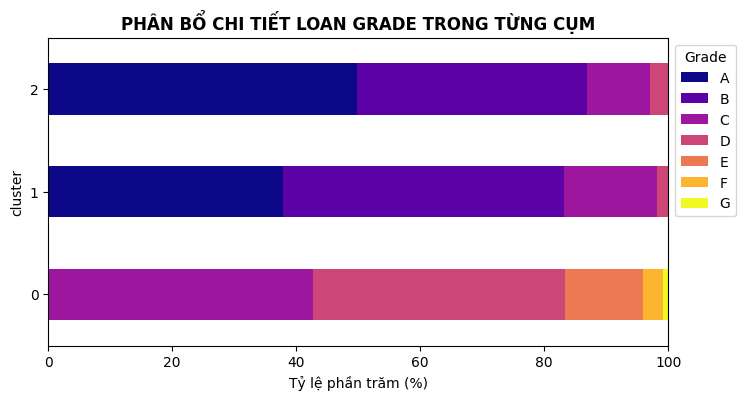

In [24]:
# Tạo bảng chéo tỷ lệ %
grade_pct = pd.crosstab(df_cleaned['cluster'], df_cleaned['loan_grade'], normalize='index') * 100

# Vẽ cột chồng
grade_pct.plot(kind='barh', stacked=True, figsize=(8, 4), cmap='plasma')
plt.title("PHÂN BỔ CHI TIẾT LOAN GRADE TRONG TỪNG CỤM", weight='bold')
plt.xlabel("Tỷ lệ phần trăm (%)")
plt.legend(title="Grade", bbox_to_anchor=(1, 1))
plt.show()

<span style="color:white; font-size:20px;"><b>Nhận xét</b></span>


 **Cụm 0: Nhóm khách hàng rủi ro cao (High Risk)**

Đây là cụm có đặc điểm tín dụng xấu nhất trong cả 3 nhóm.

* **Lịch sử tín dụng:** Có tới **75.4%** khách hàng đã từng có nợ xấu trên hồ sơ (`cb_person_default_on_file`), một tỷ lệ cực kỳ cao so với hai cụm còn lại (gần như bằng 0%).
* **Xếp hạng khoản vay (`loan_grade`):** Chủ yếu tập trung ở các nhóm **C, D, E** và có sự xuất hiện rõ rệt của **F, G**. Hầu như không có Grade A hay B. Điều này minh chứng cho mức độ rủi ro rất cao.
* **Tình trạng nhà ở (`person_home_ownership`):** Đa số là thuê nhà (**58.8%**) hoặc đang trả góp (Mortgage - **32.9%**).
* **Mục đích vay (`loan_intent`):** Khá dàn trải, nhưng tập trung nhiều vào Giáo dục (19.2%) và Y tế (18.5%).

 **Cụm 1: Nhóm khách hàng thuê nhà, rủi ro thấp (Renters - Low Risk)**

Đây là nhóm khách hàng trẻ hoặc chưa sở hữu tài sản lớn nhưng có ý thức tín dụng tốt.

* **Lịch sử tín dụng:** Gần như **0%** có nợ xấu trên hồ sơ.
* **Xếp hạng khoản vay (`loan_grade`):** Rất tốt, chủ yếu là **Grade A và B** (chiếm khoảng 85% cụm), một ít Grade C và gần như không có các nhóm rủi ro thấp hơn.
* **Tình trạng nhà ở (`person_home_ownership`):** Đặc điểm nhận dạng rõ nhất là tỷ lệ thuê nhà cực cao (**85.9%**). Họ hầu như không có nhà trả góp (0%).
* **Mục đích vay (`loan_intent`):** Tập trung nhiều nhất vào Giáo dục (20.4%), Y tế (20.8%) và Kinh doanh (18.6%).

 **Cụm 2: Nhóm khách hàng có nhà, tín dụng ưu tú (Homeowners - Elite)**

Đây được xem là nhóm khách hàng "vàng" của ngân hàng.

* **Lịch sử tín dụng:** Cực kỳ sạch, chỉ có **0.2%** từng có nợ xấu.
* **Xếp hạng khoản vay (`loan_grade`):** Tốt nhất trong 3 cụm. Tỷ lệ **Grade A** chiếm đa số (khoảng 50%), còn lại chủ yếu là Grade B.
* **Tình trạng nhà ở (`person_home_ownership`):** Gần như toàn bộ khách hàng trong cụm này đều đang sở hữu nhà có thế chấp (**99.2% Mortgage**). Đây là yếu tố ràng buộc tài sản rất mạnh.
* **Mục đích vay (`loan_intent`):** Tương tự các cụm khác nhưng có tỷ lệ vay để Cải tạo nhà cửa (`HOMEIMPROVEMENT`) cao hơn cụm 1, phù hợp với đặc điểm sở hữu nhà của họ.

**Tổng kết:** Mô hình phân cụm đã thành công trong việc tách biệt các nhóm khách hàng dựa trên đặc điểm tín dụng và tình trạng nhà ở, giúp ngân hàng có thể áp dụng các chính sách phê duyệt và lãi suất phù hợp cho từng phân khúc, từ đó tối ưu hóa lợi nhuận và giảm thiểu rủi ro nợ xấu.



<h4 style="color:green;font-weight:bold;font-size:18px;">
PHÂN LỚP VÀ ĐÁNH GIÁ MÔ HÌNH
</h4>

In [25]:
# Khởi tạo các biến mô hình
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_dt = DecisionTreeClassifier(max_depth=6, random_state=42)
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08, eval_metric='logloss')

list_models = [
    ("Logistic Regression", model_lr),
    ("Decision Tree", model_dt),
    ("Random Forest", model_rf),
    ("XGBoost", model_xgb)]

for name, model in list_models:
    model.fit(X_train_res, y_train_res)
    
    # Dự đoán trên dữ liệu test đã scale
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    print(f"\n========== MÔ HÌNH: {name} ==========")
    print(classification_report(y_test, y_pred))
    print(f"AUC Score: {roc_auc_score(y_test, y_proba):.4f}")



========== MÔ HÌNH: Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.93      0.78      0.84      7597
           1       0.49      0.79      0.61      2126

    accuracy                           0.78      9723
   macro avg       0.71      0.78      0.73      9723
weighted avg       0.83      0.78      0.79      9723

AUC Score: 0.8595

========== MÔ HÌNH: Decision Tree ==========
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7597
           1       0.75      0.77      0.76      2126

    accuracy                           0.89      9723
   macro avg       0.84      0.85      0.84      9723
weighted avg       0.89      0.89      0.89      9723

AUC Score: 0.9119

========== MÔ HÌNH: Random Forest ==========
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7597
           1       0.93      0.76      0.83      2126

  

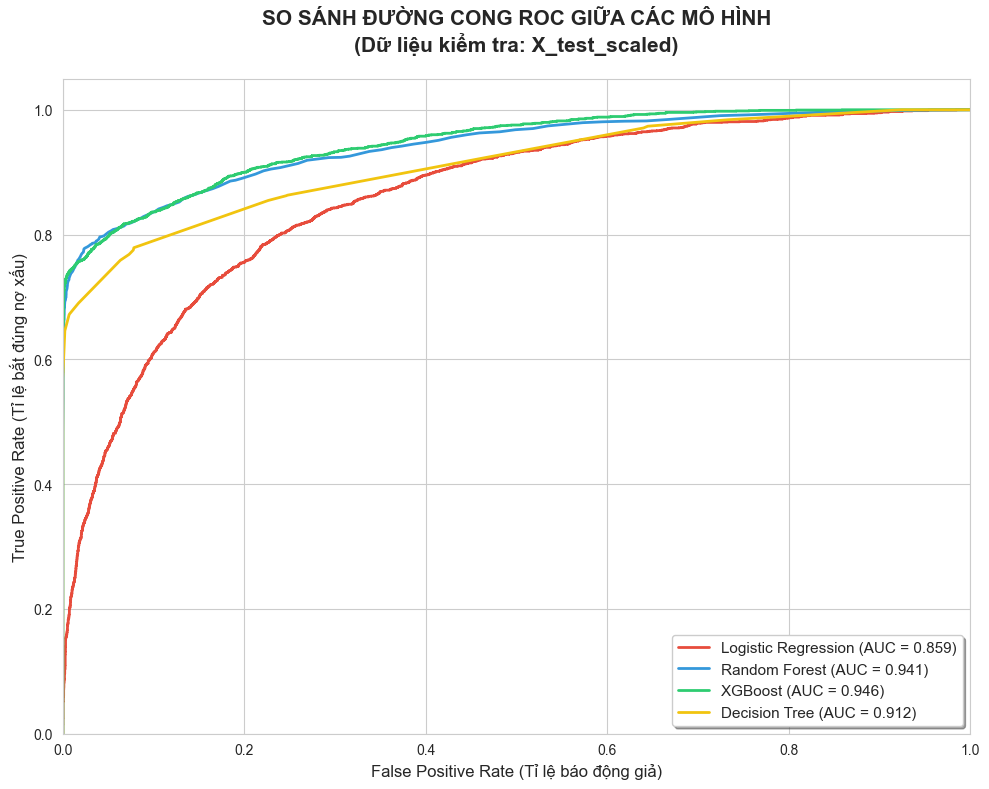

In [26]:
# SO SÁNH ĐƯỜNG CONG ROC GIỮA CÁC MÔ HÌNH

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

models_plot = [
        ('Logistic Regression', 'model_lr', '#e74c3c'),   
        ('Random Forest', 'model_rf', '#3498db'),      
        ('XGBoost', 'model_xgb', '#2ecc71'),          
        ('Decision Tree', 'model_dt', '#f1c40f')    
    ]

for label, var_name, color in models_plot:
        if var_name in globals() and globals()[var_name] is not None:
            try:
                y_proba = globals()[var_name].predict_proba(X_test_scaled)[:, 1]
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                roc_auc = auc(fpr, tpr)
                
                plt.plot(fpr, tpr, color=color, linewidth=2, linestyle='-',
                         label=f'{label} (AUC = {roc_auc:.3f})')
            except Exception as e:
                print(f"Cảnh báo: Không thể vẽ {label}. Lỗi: {e}")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Tỉ lệ báo động giả)', fontsize=12)
plt.ylabel('True Positive Rate (Tỉ lệ bắt đúng nợ xấu)', fontsize=12)
plt.title('SO SÁNH ĐƯỜNG CONG ROC GIỮA CÁC MÔ HÌNH\n(Dữ liệu kiểm tra: X_test_scaled)', fontsize=15, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
  
plt.tight_layout()
plt.savefig('roc_auc_final.png', dpi=300)
plt.show()

<span style="color:green; font-size:20px;"><b>Nhận xét và Đánh giá</b></span>

**1. Logistic Regression (Hồi quy Logistic)**

**Lớp 0 – Khách hàng không nợ xấu**
- `Precision = 0.93`: Trong các khách hàng được dự đoán là trả nợ đúng hạn, có 93% dự đoán chính xác.
- `Recall = 0.78`: Mô hình nhận diện được 78% khách hàng thực sự trả nợ đúng hạn.
- `F1-score = 0.84`: Hiệu suất tổng thể của lớp 0 ở mức khá tốt.

**Lớp 1 – Khách hàng nợ xấu**
- `Precision = 0.49`: Trong các khách hàng bị dự đoán là nợ xấu, chỉ khoảng 49% thực sự là nợ xấu.
- `Recall = 0.79`: Mô hình phát hiện được 79% khách hàng thực sự có nguy cơ nợ xấu.
- `F1-score = 0.61`: Hiệu suất tổng thể của lớp 1 còn khá thấp do precision chưa tốt.

**Đánh giá**
- Mô hình có Accuracy đạt `0.78` và AUC đạt `0.8595`, cho thấy khả năng phân biệt hai nhóm khách hàng ở mức khá tốt.
- Tuy nhiên, mô hình tạo ra khá nhiều cảnh báo sai (false positive), khiến ngân hàng có thể từ chối nhầm nhiều khách hàng có khả năng trả nợ tốt.
- Logistic Regression phù hợp làm mô hình cơ sở (baseline), nhưng chưa tối ưu cho bài toán dự báo rủi ro tín dụng.

**2. Decision Tree (Cây quyết định)**

**Lớp 0 – Khách hàng không nợ xấu**
- `Precision = 0.93`: Trong các khách hàng được dự đoán là không nợ xấu, có 93% dự đoán chính xác.
- `Recall = 0.93`: Mô hình nhận diện được 93% khách hàng thực sự không nợ xấu.
- `F1-score = 0.93`: Hiệu suất tổng thể của lớp 0 ở mức rất tốt.

**Lớp 1 – Khách hàng nợ xấu**
- `Precision = 0.75`: Trong các khách hàng bị dự đoán là nợ xấu, có 75% thực sự là nợ xấu.
- `Recall = 0.77`: Mô hình phát hiện được 77% khách hàng thực sự có nguy cơ nợ xấu.
- `F1-score = 0.76`: Hiệu suất dự báo nợ xấu khá cân bằng giữa precision và recall.

**Đánh giá**
- Mô hình đạt Accuracy `0.89` và AUC `0.9119`, cho thấy khả năng phân loại khá mạnh.
- Decision Tree xử lý tốt các mối quan hệ phi tuyến trong dữ liệu tín dụng.
- Tuy nhiên, mô hình vẫn có nguy cơ overfitting nếu dữ liệu thay đổi mạnh hoặc chứa nhiều nhiễu.


**3. Random Forest (Rừng ngẫu nhiên)**

**Lớp 0 – Khách hàng không nợ xấu**
- `Precision = 0.94`: Trong các khách hàng được dự đoán là không nợ xấu, có 94% dự đoán chính xác.
- `Recall = 0.98`: Mô hình nhận diện gần như toàn bộ khách hàng thực sự không nợ xấu.
- `F1-score = 0.96`: Hiệu suất tổng thể của lớp 0 rất cao.

**Lớp 1 – Khách hàng nợ xấu**
- `Precision = 0.93`: Trong các khách hàng dự đoán là nợ xấu, 93% thực sự là nợ xấu.
- `Recall = 0.76`: Mô hình phát hiện được 76% khách hàng thực sự có nguy cơ nợ xấu.
- `F1-score = 0.83`: Hiệu suất dự báo nợ xấu ở mức rất tốt.

**Đánh giá**
- Random Forest đạt Accuracy `0.93` và AUC `0.9409`, thuộc nhóm mô hình có hiệu suất rất cao.
- Mô hình cho thấy độ ổn định tốt và khả năng giảm nhiễu hiệu quả nhờ cơ chế kết hợp nhiều cây quyết định.
- Với precision lớp 1 rất cao (`0.93`), mô hình hỗ trợ ngân hàng xác định khá chính xác nhóm khách hàng rủi ro cao.


**4. XGBoost (Extreme Gradient Boosting)**

**Lớp 0 – Khách hàng không nợ xấu**
- `Precision = 0.93`: Trong các khách hàng được dự đoán là không nợ xấu, có 93% dự đoán chính xác.
- `Recall = 0.99`: Mô hình nhận diện gần như toàn bộ khách hàng thực sự không nợ xấu.
- `F1-score = 0.96`: Hiệu suất tổng thể của lớp 0 ở mức rất cao.

**Lớp 1 – Khách hàng nợ xấu**
- `Precision = 0.95`: Trong các khách hàng dự đoán là nợ xấu, tới 95% thực sự là nợ xấu.
- `Recall = 0.75`: Mô hình phát hiện được 75% khách hàng thực sự nguy cơ nợ xấu.
- `F1-score = 0.84`: Hiệu suất dự báo nợ xấu tốt và ổn định.

**Đánh giá**
- XGBoost là mô hình có hiệu suất cao nhất với Accuracy `0.94` và AUC `0.9462`.
- Mô hình cho khả năng phân loại rất mạnh, đặc biệt ở precision lớp 1 (`0.95`) — cao nhất trong các mô hình thử nghiệm.
- Điều này giúp giảm thiểu rủi ro phê duyệt nhầm khách hàng nợ xấu, đồng thời tối ưu hiệu quả ra quyết định tín dụng.

**Nhìn chung, XGBoost là mô hình có hiệu suất tốt nhất trong các mô hình thử nghiệm, với Accuracy và AUC cao nhất, đồng thời duy trì khả năng phát hiện nợ xấu hiệu quả. Đây là mô hình phù hợp nhất để áp dụng cho bài toán dự báo rủi ro tín dụng trong bộ dữ liệu này.**


TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT - XGBOOST
1    loan_percent_income                 0.144668
2    person_home_ownership_RENT          0.136072
3    loan_grade                          0.114174
4    person_home_ownership_OWN           0.069328
5    loan_intent_VENTURE                 0.064428
6    loan_intent_HOMEIMPROVEMENT         0.057183
7    loan_int_rate                       0.055267
8    cb_person_cred_hist_length          0.052058
9    person_income                       0.050856
10   person_emp_length                   0.049753


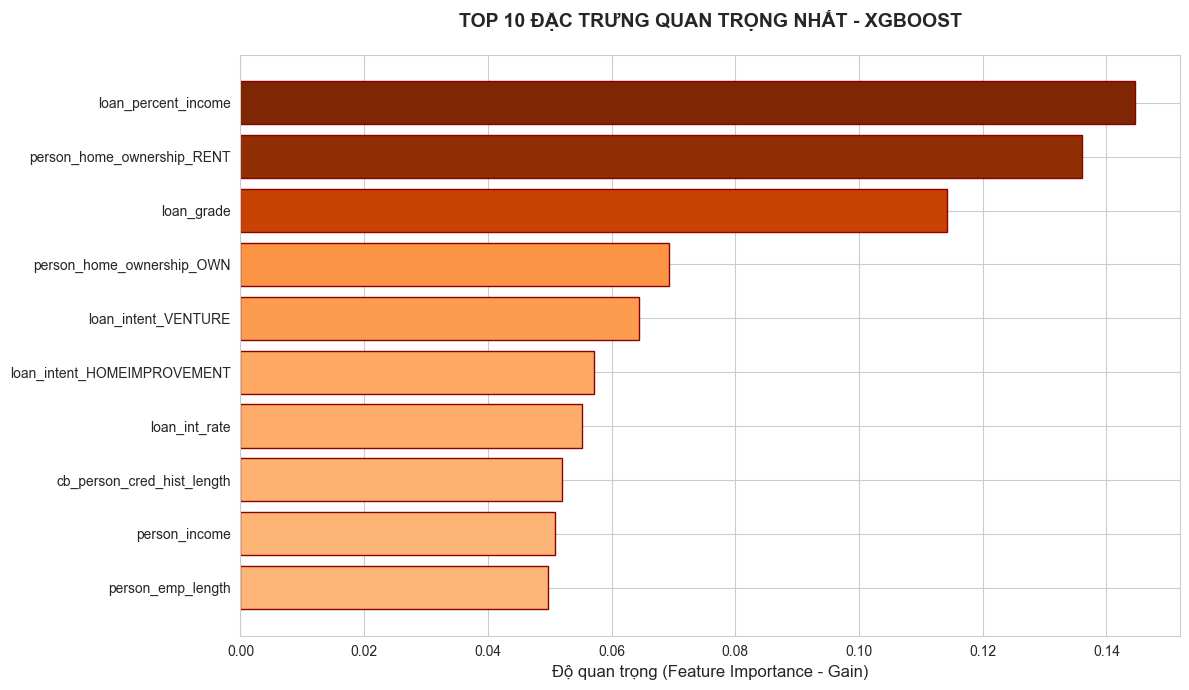

In [27]:
# TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT - XGBOOST 

feature_names = X.columns.tolist()
xgboost_model = list_models[-1][1]
importances = xgboost_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(10) 

# In bảng kết quả
print("\n" + "="*60)
print("TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT - XGBOOST")
print("="*60)
for i, (idx, row) in enumerate(importance_df.iterrows(), 1):
    print(f"{i:<4} {row['feature']:<35} {row['importance']:.6f}")

# Vẽ biểu đồ 
plt.figure(figsize=(12, 7))
colors = plt.cm.Oranges(importance_df['importance'] / importance_df['importance'].max())
bars = plt.barh(importance_df['feature'], 
                importance_df['importance'], 
                color=colors,        
                edgecolor='darkred',
                linewidth=1)

plt.xlabel("Độ quan trọng (Feature Importance - Gain)", fontsize=12)
plt.title("TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT - XGBOOST", 
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

<span style="color:white; font-size:20px;"><b>Nhận xét</b></span>

Do XGBoost là mô hình có hiệu suất tốt nhất trong quá trình thử nghiệm, nên feature importance được phân tích dựa trên mô hình này để xác định các biến ảnh hưởng mạnh nhất đến khả năng vỡ nợ.

* `loan_percent_income` là biến quan trọng nhất, cho thấy tỷ lệ khoản vay trên thu nhập có ảnh hưởng lớn đến rủi ro tín dụng.

* Các biến liên quan đến tình trạng sở hữu nhà như `person_home_ownership_RENT` và `person_home_ownership_OWN` cũng có mức ảnh hưởng cao, phản ánh sự khác biệt về mức độ ổn định tài chính giữa các nhóm khách hàng.

* `loan_grade` nằm trong nhóm đặc trưng quan trọng nhất, cho thấy hệ thống xếp hạng tín dụng có khả năng phản ánh tốt mức độ rủi ro của khoản vay.

* Các biến như `loan_int_rate`, `person_income` và `person_emp_length` tiếp tục cho thấy vai trò quan trọng trong việc đánh giá khả năng trả nợ của khách hàng.

* Nhìn chung, các đặc trưng quan trọng nhất chủ yếu liên quan đến khả năng tài chính, mức độ ổn định kinh tế và chất lượng tín dụng của người vay.
